In [3]:
from model import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import pandas as pd
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions.Generate_mixture_data import * 
import arviz as az

from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

# Plot functions

In [4]:
# ── Reusable plot functions ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from collections import defaultdict

def plot_membership_heatmap(z_map_arr, membership, C, title=""):
    """
    Heatmap of posterior cluster membership probabilities.

    Parameters
    ----------
    z_map_arr  : array-like (N,)   — MAP cluster assignment per assessor
    membership : array-like (N, C) — posterior membership probability matrix
    C          : int               — total number of clusters
    title      : str               — optional label appended to the plot title

    Returns
    -------
    active_clusters : list[int]
    cluster_sizes   : np.ndarray, shape (C,)
    """
    z_map_arr  = np.asarray(z_map_arr, dtype=int)
    membership = np.asarray(membership)
    N_assess   = z_map_arr.shape[0]

    confidence      = membership[np.arange(N_assess), z_map_arr]
    sort_ord        = np.lexsort((-confidence, z_map_arr))
    boundaries      = np.where(np.diff(z_map_arr[sort_ord]))[0]
    cluster_sizes   = np.array([(z_map_arr == c).sum() for c in range(C)])
    active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]
    mem_display     = membership[sort_ord][:, active_clusters]

    fig, ax = plt.subplots(figsize=(max(12, N_assess * 0.004 + 4),
                                    max(4, len(active_clusters) * 0.4 + 2)))
    im = ax.imshow(mem_display.T, vmin=0, vmax=1, cmap="YlOrRd",
                   aspect="auto", interpolation="nearest")
    for b in boundaries:
        ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

    ax.set_yticks(range(len(active_clusters)))
    ax.set_yticklabels(
        [f"Cluster {c}  (n={cluster_sizes[c]})" for c in active_clusters], fontsize=8)
    ax.set_xlabel("Assessor (sorted by MAP cluster, then posterior confidence)", fontsize=9)
    ax.set_ylabel("Cluster", fontsize=9)
    subtitle = f" — {title}" if title else ""
    ax.set_title(
        f"Posterior cluster membership probability{subtitle}\n"
        "(each column = one assessor  ·  white lines = MAP cluster boundaries)",
        fontsize=10,
    )
    plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()

    print(f"\n{len(active_clusters)} active clusters out of {C}")
    print(f"Cluster sizes: {', '.join(f'Cl{c}={cluster_sizes[c]}' for c in active_clusters)}")
    return active_clusters, cluster_sizes


def plot_consensus_rankings(clusters_info, z_map_arr, item_names, rankings,
                             C, min_assessors=10, title=""):
    """
    Consensus (MAP) rankings per cluster.

    Parameters
    ----------
    clusters_info : dict {c: {"blocks": list, "theta": float, "cluster_size": int}}
    z_map_arr     : array-like (N,)   — MAP cluster assignment per assessor
    item_names    : dict[int, str]    — item index to display name
    rankings      : np.ndarray (N, m) — original ranking data
    C             : int               — total number of clusters
    min_assessors : int               — skip clusters smaller than this
    title         : str               — optional label appended to the plot title

    Returns
    -------
    cluster_order : list[int] — clusters plotted (size >= min_assessors), by size desc
    """
    z_map_arr     = np.asarray(z_map_arr, dtype=int)
    cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C)])
    active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]
    cluster_order   = [c for c in active_clusters if cluster_sizes[c] >= min_assessors]
    n_ranked        = rankings.shape[1]

    if not cluster_order:
        print(f"No clusters passed the filter — lower min_assessors (currently {min_assessors}).")
        return cluster_order

    block_bg = ["#eef3fb", "#d4e6f2"]
    ncols    = len(cluster_order)
    fig, axes = plt.subplots(
        1, ncols, figsize=(ncols * 3.2, n_ranked * 0.4 + 1.5), squeeze=False)

    for col, c in enumerate(cluster_order):
        info    = clusters_info[c]
        blocks  = info["blocks"]
        theta   = info["theta"]
        n_c     = info["cluster_size"]
        total_items = sum(len(b) for b in blocks)

        ax = axes[0, col]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, total_items)
        ax.invert_yaxis()
        ax.axis("off")

        rank_pos = 1
        row_i    = 0
        for b_idx, block in enumerate(blocks):
            toggle = b_idx % 2
            for item_idx in block:
                name = item_names.get(item_idx, f"item {item_idx}")
                ax.add_patch(plt.Rectangle(
                    (0, row_i), 1, 1,
                    facecolor=block_bg[toggle], edgecolor="none", zorder=1,
                ))
                ax.text(0.05, row_i + 0.5, str(rank_pos),
                        fontsize=7, va="center", ha="left", color="#aaaaaa", zorder=2)
                ax.text(0.20, row_i + 0.5, name,
                        fontsize=8, va="center", ha="left", color="#1a1a1a", zorder=2)
                row_i += 1
            rank_pos += len(block)

        ax.set_title(
            f"Cluster {c}\n(N={n_c}, K={len(blocks)}, θ={theta:.2f})",
            fontsize=8, pad=4,
        )

    subtitle = f" — {title}" if title else ""
    fig.suptitle(f"Consensus rankings per cluster{subtitle}", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()
    print(f"Showing {ncols}/{C} clusters (filter: ≥{min_assessors} assessors)")
    return cluster_order


def plot_rank_distributions(cluster_order, cluster_sizes, z_map_arr, rankings,
                             item_names, min_assessors=10, title=""):
    """
    Box plots of observed rank distributions per cluster.

    Parameters
    ----------
    cluster_order  : list[int]        — clusters to plot (e.g. from plot_consensus_rankings)
    cluster_sizes  : array-like (C,)  — number of assessors per cluster
    z_map_arr      : array-like (N,)  — MAP cluster assignment per assessor
    rankings       : np.ndarray (N, m)— original ranking data (preference orderings)
    item_names     : dict[int, str]   — item index to display name
    min_assessors  : int              — skip clusters smaller than this
    title          : str              — optional label appended to the plot title
    """
    z_map_arr     = np.asarray(z_map_arr, dtype=int)
    cluster_sizes = np.asarray(cluster_sizes)
    cluster_order = [c for c in cluster_order if cluster_sizes[c] >= min_assessors]
    n_ranked      = rankings.shape[1]

    if not cluster_order:
        print(f"No clusters to plot — lower min_assessors (currently {min_assessors}).")
        return

    rank_cmap = mcolors.LinearSegmentedColormap.from_list(
        "blue_purple_red", ["#3355cc", "#8844aa", "#cc3333"]
    )
    ncols_bp = len(cluster_order)
    fig_bp, axes_bp = plt.subplots(
        1, ncols_bp,
        figsize=(ncols_bp * 2.8, n_ranked * 0.35 + 1.2),
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        cl_assessors = np.where(z_map_arr == c)[0]

        item_ranks = defaultdict(list)
        for ai in cl_assessors:
            for rank_0, item_idx in enumerate(rankings[ai]):
                item_ranks[item_idx].append(rank_0 + 1)  # 1-indexed

        stats = []
        for item_idx, ranks_list in item_ranks.items():
            arr = np.array(ranks_list)
            stats.append({
                "item":   item_idx,
                "name":   item_names.get(item_idx, f"item {item_idx}"),
                "median": np.median(arr),
                "ranks":  ranks_list,
            })
        stats.sort(key=lambda x: x["median"])

        ax       = axes_bp[0, col]
        names    = [s["name"]   for s in stats]
        medians  = [s["median"] for s in stats]
        rank_data = [s["ranks"] for s in stats]

        rank_norm  = mcolors.Normalize(vmin=min(medians), vmax=max(medians))
        box_colors = [rank_cmap(rank_norm(m)) for m in medians]

        bp = ax.boxplot(
            rank_data, vert=False, patch_artist=True,
            widths=0.55,
            flierprops=dict(marker=".", markersize=3, markerfacecolor="#555555",
                            markeredgecolor="#555555", alpha=0.6),
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(color="#555555", linewidth=0.8),
            capprops=dict(color="#555555", linewidth=0.8),
        )
        for patch, fc in zip(bp["boxes"], box_colors):
            patch.set_facecolor(fc)
            patch.set_edgecolor("#333333")
            patch.set_linewidth(0.6)
            patch.set_alpha(0.85)

        ax.set_yticks(range(1, len(stats) + 1))
        ax.set_yticklabels(names, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel("Rank", fontsize=7)
        ax.set_title(f"Cluster {c}  (N={cluster_sizes[c]})", fontsize=8, pad=4)
        ax.tick_params(axis="x", labelsize=6)
        ax.set_xlim(0, n_ranked + 1)

    subtitle = f" — {title}" if title else ""
    fig_bp.suptitle(
        f"Observed rank distributions per cluster{subtitle}",
        fontsize=10, y=1.01,
    )
    fig_bp.tight_layout()
    plt.show()


# Download data

In [2]:
import urllib.request
import numpy as np

# Download the "sushi3" archive from Kamishima's site
url = "https://www.kamishima.net/asset/sushi3-2016.zip"
urllib.request.urlretrieve(url, "sushi3.zip")

import zipfile
with zipfile.ZipFile("sushi3.zip", "r") as z:
    z.extractall("sushi3")

Sushi3a rankings: same 10 items ranked

In [5]:
# Parse sushi3a rankings
# Format: each line is "<user_id> <n_items> <rank_1> ... <rank_10>"
# First line is a header
rankings = []
with open("sushi3/sushi3-2016/sushi3a.5000.10.order") as f:
    for i, line in enumerate(f):
        if i == 0:
            continue  # skip header
        parts = line.strip().split()
        ranking = [int(x) for x in parts[2:]]  # skip user_id and n_items
        rankings.append(ranking)

rankings = np.array(rankings)  # shape (5000, 10)
print(f"Rankings: {rankings.shape[0]} assessors, {rankings.shape[1]} sushi types")
print(f"Items: {sorted(np.unique(rankings))}")

Rankings: 5000 assessors, 10 sushi types
Items: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Sushi3b dataset. subset of 100 items

In [6]:
rankings = []
with open("sushi3/sushi3-2016/sushi3b.5000.10.order") as f:
    for i, line in enumerate(f):
        if i == 0:
            continue
        parts = line.strip().split()
        ranking = [int(x) for x in parts[2:]]
        rankings.append(ranking)

rankings = np.array(rankings)  # should be (5000, 100)
print(f"Rankings: {rankings.shape[0]} assessors, {rankings.shape[1]} sushi types")

Rankings: 5000 assessors, 10 sushi types


In [6]:
# ── Sushi item names for ITEM SET A (sushi3a) ─────────────────────────────────
# NB: Item set A has DIFFERENT items 5-9 than item set B!
#   A: 5=ikura, 6=tamago, 7=toro, 8=tekka_maki, 9=kappa_maki
#   B: 5=tako,  6=ikura,  7=tamago, 8=toro,      9=amaebi
sushi_names = {
    0: "Shrimp (ebi)",
    1: "Sea eel (anago)",
    2: "Tuna (maguro)",
    3: "Squid (ika)",
    4: "Sea urchin (uni)",
    5: "Salmon roe (ikura)",
    6: "Egg (tamago)",
    7: "Fatty tuna (toro)",
    8: "Tuna roll (tekka maki)",
    9: "Cucumber roll (kappa maki)",
}

n_ranked = rankings.shape[1]
print(f"Sushi items in rankings (item set A): {n_ranked}")
for i in range(n_ranked):
    print(f"  {i}: {sushi_names[i]}")

Sushi items in rankings (item set A): 10
  0: Shrimp (ebi)
  1: Sea eel (anago)
  2: Tuna (maguro)
  3: Squid (ika)
  4: Sea urchin (uni)
  5: Salmon roe (ikura)
  6: Egg (tamago)
  7: Fatty tuna (toro)
  8: Tuna roll (tekka maki)
  9: Cucumber roll (kappa maki)


# Run single model

In [3]:
C = 10
gamma = 1
delta = 0.5

# Initate with spectral clustering
clusters, z_init = init_spectral_with_z(
    rankings=rankings,
    n_clusters=C,
    py_sampling=False,  # Use simpler ~n/2 blocks
    gamma=gamma,
    delta=delta,
    seed=42
    )

In [4]:
n_iter = 50000 #50000 # Same as Bayesian Rank Clustering paper
burn_in = 30000
thin = 1
seed = 42
C = 10
N = rankings.shape[0]
m = rankings.shape[1]

mu_collapse   = 0.0001          # your current setting — promotes sparsity
mu_uniform    = 1.0           # no preference
mu_balanced   = N / C         # strong pull toward equal clusters 
mu_soft       = N / (C * m)   # softer balance prior 

init_mu = [mu_collapse for _ in range(C)] 

model_partial = MixtureRankingModel(
    rankings=rankings,
    init_clusters=clusters,
    init_z=z_init,
    #n_clusters=C,
    init_mu=init_mu,
    seed=seed,
    verbose=True,
    init_theta=1.0,
)

final_state_partial, samples_partial = model_partial.run_mcmc(
    n_iter=n_iter,
    burn_in=burn_in,
    thin=thin,
    use_py_prior=False,
    include_order_prior=False,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    a_theta=2,
    b_theta=1,
    save_log_likelihood=True,
    theta_jump=10,
    ranking_jump=1,              # augment missing drivers every 5th iteration
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

model_partial.print_acceptance_summary()

if samples_partial is not None:
    summaries_partial = model_partial.estimate_map(samples_partial, ci=0.95)
    print("MAP summaries:", summaries_partial)


[Model] Initialized: N=5000 assessors, n=10 items, C=10 clusters, n_pairs=45
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    5000×45  (0.9 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 5 blocks, theta=1.000, gamma=1.000, delta=0.500

[MCMC] Starting run: n_iter=50000, burn_in=30000, thin=1, theta_jump=10
[MCMC] Item moves per cluster: 1
[MCMC] Will save 20000 iterations after burn-in

[M

C:\Users\jonanord\AppData\Local\Temp\ipykernel_21996\810887111.py:50: DeprecationWarning: estimate_map() is deprecated and will be removed in a future version. Use find_map(method='frequency', ci=...) instead.
  summaries_partial = model_partial.estimate_map(samples_partial, ci=0.95)


MAP summaries: {'N': 5000, 'C': 10, 'T': 20000, 'labels': {'p_ic': [[0.0, 0.0395, 0.0, 0.0, 0.0, 0.0, 0.0216, 0.05305, 0.88525, 0.0006], [0.0, 0.0003, 0.0, 0.0, 0.0, 0.0, 0.0131, 5e-05, 0.89255, 0.094], [0.0, 0.0655, 0.0, 0.0, 0.0, 0.0, 0.1679, 0.4686, 0.00765, 0.29035], [0.0, 0.20935, 0.0, 0.0, 0.0, 0.0, 0.0018, 0.7886, 0.0002, 5e-05], [0.0, 0.00115, 0.0, 0.0, 0.0, 0.0, 0.24525, 0.00275, 0.73305, 0.0178], [0.0, 0.0043, 0.0, 0.0, 0.0, 0.0, 0.08485, 0.0033, 0.8708, 0.03675], [0.0, 0.54845, 0.0, 0.0, 0.0, 0.0, 0.003, 0.43445, 0.0013, 0.0128], [0.0, 0.00085, 0.0, 0.0, 0.0, 0.0, 0.0321, 0.0004, 0.5825, 0.38415], [0.0, 0.04645, 0.0, 0.0, 0.0, 0.0, 0.2795, 0.19975, 0.017, 0.4573], [0.0, 0.0011, 0.0, 0.0, 0.0, 0.0, 0.0027, 0.0001, 0.91925, 0.07685], [0.0, 0.0073, 0.0, 0.0, 0.0, 0.0, 0.47325, 0.0253, 0.01235, 0.4818], [0.0, 0.90545, 0.0, 0.0, 0.0, 0.0, 0.0015, 0.0891, 0.00115, 0.0028], [0.0, 0.57555, 0.0, 0.0, 0.0, 0.0, 0.00135, 0.42255, 0.00035, 0.0002], [0.0, 0.00255, 0.0, 0.0, 0.0, 0.0, 0.0

## Save run

In [11]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# ── Save run ──────────────────────────────────────────────────────────────────
SUSHI_RUNS_DIR = Path("sushi3/runs")
run_name = f"sushi_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir  = SUSHI_RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

mcmc_params = dict(
    n_assessors             = len(rankings),
    n_items                 = rankings.shape[1],
    C                       = C,
    gamma                   = gamma,
    delta                   = delta,
    n_iter                  = n_iter,
    burn_in                 = burn_in,
    thin                    = thin,
    n_item_moves_per_cluster= 1,
    a_theta                 = 2,
    b_theta                 = 1,
    theta_jump              = 10,
    ranking_jump            = 1,
    use_annealing           = True,
    temp_min                = 0.1,
    temp_max                = 1.0,
    run_name                = run_name,
    saved_at                = datetime.now().isoformat(),
)
with open(run_dir / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params, f, indent=2)

with open(run_dir / "samples.pkl", "wb") as f:
    pickle.dump(samples_partial, f)

with open(run_dir / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_partial, f)

print(f"Run saved to: {run_dir}")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<25}  {p.stat().st_size / 1024:>8.1f} KB")


Run saved to: sushi3\runs\sushi_20260604_130208
  final_state.pkl                40.2 KB
  mcmc_params.json                0.4 KB
  samples.pkl                1675144.9 KB


## Load run


In [4]:
import json
import pickle
from pathlib import Path
from datetime import datetime


# ── Select run to load ────────────────────────────────────────────────────────
RUN_NAME = "sushi_20260604_130208"  # or replace with a specific folder name, e.g. "sushi_20260604_120000"
run_dir  = Path("sushi3/runs") / RUN_NAME

# ── 1. MCMC parameters ───────────────────────────────────────────────────────
with open(run_dir / "mcmc_params.json") as f:
    mcmc_params = json.load(f)

C       = mcmc_params["C"]
gamma   = mcmc_params.get("gamma", 1)
delta   = mcmc_params.get("delta", 0.5)
n_iter  = mcmc_params["n_iter"]
burn_in = mcmc_params["burn_in"]
thin    = mcmc_params["thin"]

print(f"Run: {RUN_NAME}")
print(f"  C={C}, n_assessors={mcmc_params['n_assessors']}, n_items={mcmc_params['n_items']}")

# ── 2. MCMC samples ──────────────────────────────────────────────────────────
with open(run_dir / "samples.pkl", "rb") as f:
    samples_partial = pickle.load(f)

# ── 3. Final model state ─────────────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "rb") as f:
    final_state_partial = pickle.load(f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nLoaded successfully:")
print(f"  {len(samples_partial.z_samples)} posterior samples")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<25}  {p.stat().st_size / 1024:>8.1f} KB")


Run: sushi_20260604_130208
  C=10, n_assessors=5000, n_items=10

Loaded successfully:
  20000 posterior samples
  final_state.pkl                40.2 KB
  mcmc_params.json                0.4 KB
  samples.pkl                1675144.9 KB


## Evaluation

In [5]:
import numpy as np
import arviz as az

ll_matrix = np.array(samples_partial.log_likelihood)  # (T, N)
T, N = ll_matrix.shape

idata = az.from_dict({
    "posterior": {"dummy": np.zeros((1, T))},
    "log_likelihood": {"rankings": ll_matrix[np.newaxis]}  # (1, T, N)
})

loo_result = az.loo(idata, var_name="rankings", pointwise=True)

print(f"ELPD LOO: {loo_result.elpd:.2f}  (SE: {loo_result.se:.2f})")
print(f"p_loo:    {loo_result.p:.2f}")

pareto_k = loo_result.pareto_k.values 
good_k = loo_result.good_k             

print(f"\nPareto-k threshold (good_k): {good_k:.3f}")
print(f"  k < {good_k:.2f} (good):  {(pareto_k < good_k).sum()}")
print(f"  k > {good_k:.2f} (bad):   {((pareto_k >= good_k) & (pareto_k < 1.0)).sum()}")
print(f"  k > 1.0  (very bad):      {(pareto_k >= 1.0).sum()}")

bad = np.where(pareto_k > good_k)[0]
if len(bad):
    print(f"\nProblematic assessors: {bad}")
    print(f"k values: {pareto_k[bad].round(3)}")

ELPD LOO: -68432.72  (SE: 121.79)
p_loo:    228.37

Pareto-k threshold (good_k): 0.700
  k < 0.70 (good):  4899
  k > 0.70 (bad):   65
  k > 1.0  (very bad):      36

Problematic assessors: [  26   35  141  196  208  314  341  363  474  680  797  825  840  864
  946  954 1033 1041 1090 1148 1176 1178 1196 1272 1274 1378 1482 1620
 1648 1688 1780 1806 1853 2008 2019 2029 2039 2145 2154 2167 2169 2483
 2500 2511 2539 2593 2663 2664 2728 2742 2787 2819 2865 2918 2977 3066
 3250 3281 3326 3341 3364 3372 3395 3422 3487 3522 3628 3694 3718 3729
 3743 3766 3857 3886 3919 3951 3970 4037 4066 4088 4126 4163 4165 4195
 4287 4351 4375 4485 4595 4607 4615 4654 4780 4808 4867 4891 4904 4949
 4950 4973 4980]
k values: [0.771 1.08  0.765 0.97  0.793 1.506 0.976 0.978 0.881 0.936 0.761 0.817
 0.938 0.998 1.301 0.953 1.048 0.736 1.199 0.937 0.744 0.77  0.74  0.851
 1.085 0.802 0.821 0.738 0.736 0.787 1.038 0.86  1.456 0.951 0.789 0.848
 1.001 0.736 0.747 0.911 1.302 0.926 0.728 1.426 1.659 0.738 0.727 

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


ELPD LOO: -68455.33  (SE: 121.82) (5 clusters)
ELPD LOO: -69125.99  (SE: 124.30) (2 clusters)

In [6]:
from model.summaries import medoid_from_samples

results = medoid_from_samples(
    samples_partial,
    rankings=rankings,       # needed for ICM refinement
    gamma=gamma,
    delta=delta,
    thin=10,
    theta_method="conditional_map",
    min_cluster_size=10,
)

z_map      = results["z_map"]        # int array, shape (N,)
membership = results["membership"]   # float array, shape (N, C)

for c, res in results.items():
    if not isinstance(c, int):
        continue
    print(f"Cluster {c}: θ={res['theta']:.3f}, {len(res['blocks'])} blocks, "
          f"n={res['cluster_size']}, avg_dist={res['avg_distance']:.1f}, "
          f"ICM: {res['icm_moves']} moves in {res['icm_sweeps']} sweeps")


  Cluster 1: 2 ICM moves in 2 sweeps, K=7 blocks
  Cluster 6: 2 ICM moves in 2 sweeps, K=6 blocks
  Cluster 7: 2 ICM moves in 2 sweeps, K=6 blocks
  Cluster 8: 0 ICM moves in 1 sweeps, K=4 blocks
  Cluster 9: 0 ICM moves in 1 sweeps, K=7 blocks
Cluster 1: θ=0.506, 7 blocks, n=1302, avg_dist=2.1, ICM: 2 moves in 2 sweeps
Cluster 6: θ=0.515, 6 blocks, n=760, avg_dist=0.2, ICM: 2 moves in 2 sweeps
Cluster 7: θ=0.577, 6 blocks, n=1276, avg_dist=1.2, ICM: 2 moves in 2 sweeps
Cluster 8: θ=0.333, 4 blocks, n=625, avg_dist=0.1, ICM: 0 moves in 1 sweeps
Cluster 9: θ=0.528, 7 blocks, n=1037, avg_dist=0.0, ICM: 0 moves in 1 sweeps


## Ploting

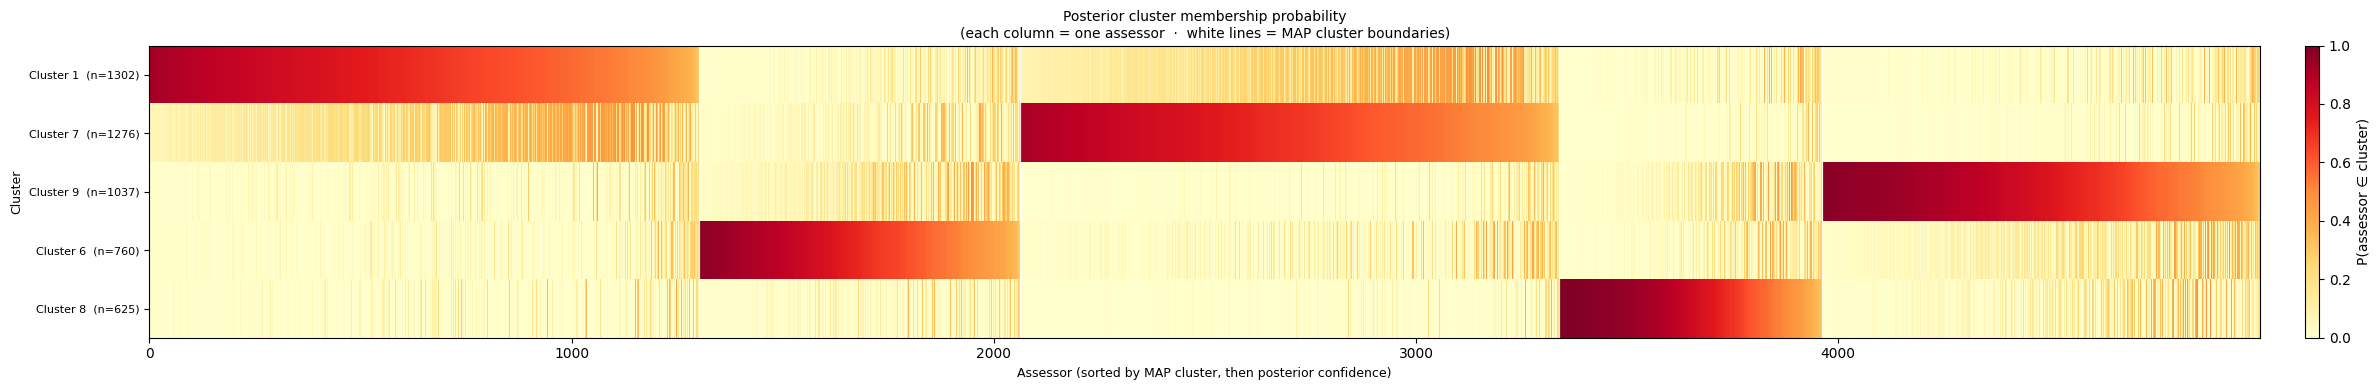


5 active clusters out of 10
Cluster sizes: Cl1=1302, Cl7=1276, Cl9=1037, Cl6=760, Cl8=625


In [ ]:
# ── Posterior cluster membership heatmap ──────────────────────────────────────
active_clusters, cluster_sizes = plot_membership_heatmap(
    results["z_map"], results["membership"], C
)


In [21]:
# ── Consensus rankings per cluster ────────────────────────────────────────────
clusters_info = {c: results[c] for c in range(C) if c in results}
cluster_order = plot_consensus_rankings(
    clusters_info, results["z_map"], sushi_names, rankings, C, min_assessors=10
)


KeyError: 'z_map'

# Test multiple clusters


  Fitting K = 6

MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2508/4999
Log-posterior improvement rate: 50.17%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 32 accepts, acceptance_rate=0.64%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 2 accepts, acceptance_rate=0.04%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 307 accepts, acceptance_rate=6.14%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Mean across clusters: 1.14%

Theta updates acceptance (theta-update iterations = 500):
  Cluster 0: 56 accepts, acceptance_rate=11.20%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 74 accepts, acceptance_rate=14.80%
  Cluster 5: 76 accepts, acceptance_rate=15.20%
  Mean across clusters: 6.87%




c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  ELPD LOO : -68826.10  (SE: 119.04)
  p_loo    : 50.52  (expected ~65)
  Pareto-k : 4995 good, 5 bad, 0 very bad

  Fitting K = 7

MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2498/4999
Log-posterior improvement rate: 49.97%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 11 accepts, acceptance_rate=0.22%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 85 accepts, acceptance_rate=1.70%
  Cluster 3: 48 accepts, acceptance_rate=0.96%
  Cluster 4: 347 accepts, acceptance_rate=6.94%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 0 accepts, acceptance_rate=0.00%
  Mean across clusters: 1.40%

Theta updates acceptance (theta-update iterations = 500):
  Cluster 0: 59 accepts, acceptance_rate=11.80%
  Cluster 1: 56 accepts, acceptance_rate=11.20%
  Cluster 2: 77 accepts, acceptance_rate=15.40%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 71 accepts, acceptance_rate=14.20%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 0 

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  ELPD LOO : -68630.10  (SE: 119.82)
  p_loo    : 36.08  (expected ~76)
  Pareto-k : 4425 good, 575 bad, 368 very bad

  Fitting K = 8

MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2497/4999
Log-posterior improvement rate: 49.95%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 158 accepts, acceptance_rate=3.16%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 111 accepts, acceptance_rate=2.22%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 0 accepts, acceptance_rate=0.00%
  Cluster 7: 0 accepts, acceptance_rate=0.00%
  Mean across clusters: 0.67%

Theta updates acceptance (theta-update iterations = 500):
  Cluster 0: 9 accepts, acceptance_rate=1.80%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 74 accepts, acceptance_rate=14.80%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 106 a

...

  ELPD LOO : -68832.95  (SE: 119.00)
  p_loo    : 61.70  (expected ~87)
  Pareto-k : 4987 good, 13 bad, 5 very bad

  Fitting K = 9

MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2479/4999
Log-posterior improvement rate: 49.59%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 0 accepts, acceptance_rate=0.00%
  Cluster 1: 96 accepts, acceptance_rate=1.92%
  Cluster 2: 1 accepts, acceptance_rate=0.02%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 125 accepts, acceptance_rate=2.50%
  Cluster 5: 192 accepts, acceptance_rate=3.84%
  Cluster 6: 0 accepts, acceptance_rate=0.00%
  Cluster 7: 1 accepts, acceptance_rate=0.02%
  Cluster 8: 37 accepts, acceptance_rate=0.74%
  Mean across clusters: 1.00%

Theta updates acceptance (theta-update iterations = 500):
  Cluster 0: 50 accepts, acceptance_rate=10.00%
  Cluster 1: 68 accepts, acceptance_rate=13.60%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 41 a

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  ELPD LOO : -68447.77  (SE: 122.39)
  p_loo    : 70.00  (expected ~98)
  Pareto-k : 4996 good, 4 bad, 0 very bad

  Fitting K = 10

MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2514/4999
Log-posterior improvement rate: 50.29%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 35 accepts, acceptance_rate=0.70%
  Cluster 1: 41 accepts, acceptance_rate=0.82%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 3 accepts, acceptance_rate=0.06%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 62 accepts, acceptance_rate=1.24%
  Cluster 7: 64 accepts, acceptance_rate=1.28%
  Cluster 8: 0 accepts, acceptance_rate=0.00%
  Cluster 9: 0 accepts, acceptance_rate=0.00%
  Mean across clusters: 0.41%

Theta updates acceptance (theta-update iterations = 500):
  Cluster 0: 75 accepts, acceptance_rate=15.00%
  Cluster 1: 78 accepts, acceptance_rate=15.60%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 acce

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  ELPD LOO : -68543.39  (SE: 121.75)
  p_loo    : 70.10  (expected ~109)
  Pareto-k : 4976 good, 24 bad, 9 very bad

  Model selection summary
        ELPD      SE  p_loo  n_bad_k  n_very_bad   ΔELPD   SE(Δ)  z vs K-1
K                                                                         
6  -68826.10  119.04  50.52        5           0 -378.33     NaN       NaN
7  -68630.10  119.82  36.08      575         368 -182.33  168.90      1.16
8  -68832.95  119.00  61.70       13           5 -385.17  168.87     -1.20
9  -68447.77  122.39  70.00        4           0    0.00  170.70      2.26
10 -68543.39  121.75  70.10       24           9  -95.62  172.64     -0.55


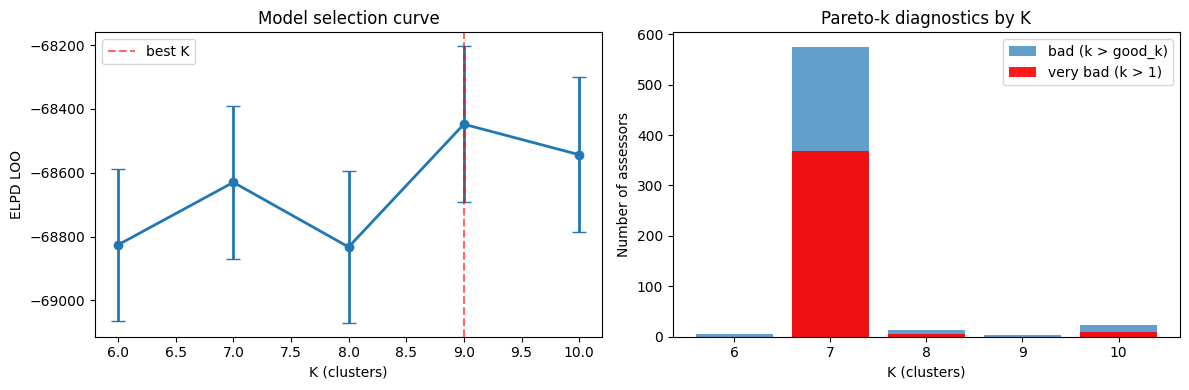

In [ ]:
import numpy as np
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
n_iter  = 20000
burn_in = 7000
thin    = 1
seed    = 42
gamma = 1
delta = 0.5

N = rankings.shape[0]
m = rankings.shape[1]

K_values = [6, 7, 8, 9, 10]
    
# ── Run ───────────────────────────────────────────────────────────────────────
results = {}

for C in K_values:
    print(f"\n{'='*50}")
    print(f"  Fitting K = {C}")
    print(f"{'='*50}")

    init_mu = [0.0001] * C  # uniform prior for all runs — fair comparison

    # Initate with spectral clustering
    clusters, z_init = init_spectral_with_z(
        rankings=rankings,
        n_clusters=C,
        py_sampling=False,  # Use simpler ~n/2 blocks
        gamma=gamma,
        delta=delta,
        seed=42
        )

    model = MixtureRankingModel(
        rankings=rankings,
        init_clusters=clusters,
        init_z=z_init,
        #n_clusters=C,
        init_mu=init_mu,
        seed=seed,
        verbose=False,       # suppress per-iteration output
        init_theta=1.0,
    )

    _, samples = model.run_mcmc(
        n_iter=n_iter,
        burn_in=burn_in,
        thin=thin,
        use_py_prior=False,
        include_order_prior=False,
        save_samples=True,
        save_tau=True,
        save_theta=True,
        n_item_moves_per_cluster=1,
        a_theta=2,
        b_theta=1,
        save_log_likelihood=True,
        theta_jump=10,
        ranking_jump=1,
        use_annealing=True,
        temp_min=0.1,
        temp_max=1.0,
    )

    model.print_acceptance_summary()

    # ── LOO ───────────────────────────────────────────────────────────────────
    ll_matrix = np.array(samples.log_likelihood)  # (T, N)
    T = ll_matrix.shape[0]

    idata = az.from_dict({
        "posterior":        {"dummy": np.zeros((1, T))},
        "log_likelihood":   {"rankings": ll_matrix[np.newaxis]},  # (1, T, N)
    })

    loo = az.loo(idata, var_name="rankings", pointwise=True)

    pareto_k  = loo.pareto_k.values
    results[C] = {
        "loo":        loo,
        "elpd":       loo.elpd,
        "se":         loo.se,
        "p_loo":      loo.p,
        "good_k":     loo.good_k,
        "n_bad_k":    (pareto_k >= loo.good_k).sum(),
        "n_very_bad": (pareto_k >= 1.0).sum(),
        "pareto_k":   pareto_k,
        "samples":    samples,
    }

    print(f"  ELPD LOO : {loo.elpd:.2f}  (SE: {loo.se:.2f})")
    print(f"  p_loo    : {loo.p:.2f}  (expected ~{C*m + C - 1})")
    print(f"  Pareto-k : {(pareto_k < loo.good_k).sum()} good, "
          f"{results[C]['n_bad_k']} bad, "
          f"{results[C]['n_very_bad']} very bad")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  Model selection summary")
print(f"{'='*60}")

df = pd.DataFrame({
    "K":          K_values,
    "ELPD":       [results[C]["elpd"]       for C in K_values],
    "SE":         [results[C]["se"]         for C in K_values],
    "p_loo":      [results[C]["p_loo"]      for C in K_values],
    "n_bad_k":    [results[C]["n_bad_k"]    for C in K_values],
    "n_very_bad": [results[C]["n_very_bad"] for C in K_values],
}).set_index("K")

# ELPD difference vs best model
best_elpd = df["ELPD"].max()
df["ΔELPD"]  = df["ELPD"] - best_elpd

# SE on pairwise differences vs neighbouring K
delta_se = [np.nan]
for i in range(1, len(K_values)):
    C_cur, C_prv = K_values[i], K_values[i-1]
    se = np.sqrt(results[C_cur]["se"]**2 + results[C_prv]["se"]**2)
    delta_se.append(se)
df["SE(Δ)"] = delta_se

# z-score vs previous K
df["z vs K-1"] = df["ΔELPD"].diff() / np.array(delta_se)

print(df.round(2).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: ELPD curve with error bars
ax = axes[0]
ax.errorbar(K_values, df["ELPD"], yerr=2*df["SE"],
            marker="o", capsize=5, linewidth=2)
ax.axvline(K_values[df["ELPD"].argmax()], linestyle="--",
           color="red", alpha=0.6, label=f"best K")
ax.set_xlabel("K (clusters)")
ax.set_ylabel("ELPD LOO")
ax.set_title("Model selection curve")
ax.legend()

# Right: Pareto-k bad count
ax = axes[1]
ax.bar(K_values, df["n_bad_k"], label="bad (k > good_k)", alpha=0.7)
ax.bar(K_values, df["n_very_bad"], label="very bad (k > 1)", alpha=0.9, color="red")
ax.set_xlabel("K (clusters)")
ax.set_ylabel("Number of assessors")
ax.set_title("Pareto-k diagnostics by K")
ax.legend()

plt.tight_layout()
plt.savefig("timm_model_selection.png", dpi=150)
plt.show() 

# Stability study — K=10, multiple MCMC seeds, shared spectral initialisation

In [ ]:
import json
import pickle
import numpy as np
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.metrics import adjusted_rand_score

# ── Config ────────────────────────────────────────────────────────────────────
C_stab   = 10
n_iter   = 50000
burn_in  = 30000
thin     = 1
gamma    = 1
delta    = 0.5
seeds    = [42, 123, 456, 789, 1337, 2024, 42+10000, 42+20000, 42+30000, 42+40000]
min_assessors = 10

# ── Output directory (created once before the loop) ───────────────────────────
STAB_RUNS_DIR = Path("sushi3/runs")
stab_run_name = f"sushi_stability_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
stab_dir      = STAB_RUNS_DIR / stab_run_name
stab_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving stability runs to: {stab_dir}\n")

# ── One shared spectral initialisation ───────────────────────────────────────
print("Running spectral initialisation (shared across all seeds)…")
clusters_init, z_init_shared = init_spectral_with_z(
    rankings=rankings,
    n_clusters=C_stab,
    py_sampling=False,
    gamma=gamma,
    delta=delta,
    seed=42,
)
print(f"  Spectral init: {len(set(z_init_shared))} clusters populated\n")

# Save shared meta immediately so the directory is self-describing
meta = dict(
    n_assessors = int(rankings.shape[0]),
    n_items     = int(rankings.shape[1]),
    C           = C_stab,
    gamma       = gamma,
    delta       = delta,
    n_iter      = n_iter,
    burn_in     = burn_in,
    thin        = thin,
    seeds       = seeds,
    run_name    = stab_run_name,
    saved_at    = datetime.now().isoformat(),
)
with open(stab_dir / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# ── Run MCMC for each seed — save immediately after each seed ─────────────────
stab_runs = {}

for seed in seeds:
    print(f"{'='*52}")
    print(f"  Seed {seed}")
    print(f"{'='*52}")

    model = MixtureRankingModel(
        rankings=rankings,
        init_clusters=clusters_init,
        init_z=z_init_shared,
        init_mu=[0.0001] * C_stab,
        seed=seed,
        verbose=False,
        init_theta=1.0,
    )

    _, samples = model.run_mcmc(
        n_iter=n_iter,
        burn_in=burn_in,
        thin=thin,
        use_py_prior=False,
        include_order_prior=False,
        save_samples=True,
        save_tau=True,
        save_theta=True,
        n_item_moves_per_cluster=1,
        a_theta=2,
        b_theta=1,
        save_log_likelihood=True,
        theta_jump=10,
        ranking_jump=1,
        use_annealing=True,
        temp_min=0.1,
        temp_max=1.0,
    )

    # LOO
    ll_matrix = np.array(samples.log_likelihood)
    T = ll_matrix.shape[0]
    idata = az.from_dict({
        "posterior":      {"dummy": np.zeros((1, T))},
        "log_likelihood": {"rankings": ll_matrix[np.newaxis]},
    })
    loo = az.loo(idata, var_name="rankings", pointwise=True)

    # MAP consensus
    res = medoid_from_samples(
        samples,
        rankings=rankings,
        gamma=gamma,
        delta=delta,
        thin=10,
        theta_method="conditional_map",
        min_cluster_size=min_assessors,
    )

    z_map_s  = res["z_map"]
    n_active = int((np.bincount(z_map_s, minlength=C_stab) > 0).sum())
    sizes    = np.bincount(z_map_s, minlength=C_stab)

    stab_runs[seed] = dict(
        samples  = samples,
        results  = res,
        loo      = loo,
        elpd     = float(loo.elpd),
        se       = float(loo.se),
        z_map    = z_map_s,
        n_active = n_active,
        sizes    = sizes,
    )

    print(f"  ELPD = {loo.elpd:.1f}  SE = {loo.se:.1f}  |  "
          f"active clusters = {n_active}  |  "
          f"sizes = {sorted(sizes[sizes > 0], reverse=True)}")

    # ── Save this seed immediately ─────────────────────────────────────────────
    seed_dir = stab_dir / f"seed_{seed}"
    seed_dir.mkdir(exist_ok=True)

    with open(seed_dir / "samples.pkl", "wb") as f:
        pickle.dump(samples, f)

    diag = dict(
        seed     = seed,
        elpd     = float(loo.elpd),
        se       = float(loo.se),
        n_active = n_active,
        sizes    = sizes.tolist(),
        z_map    = z_map_s.tolist(),
    )
    with open(seed_dir / "diagnostics.json", "w") as f:
        json.dump(diag, f, indent=2)

    print(f"  → Saved to {seed_dir.relative_to(STAB_RUNS_DIR)}")

print(f"\nAll seeds saved to: {stab_dir}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  Stability summary")
print(f"{'='*60}")

rows = []
for seed in seeds:
    r = stab_runs[seed]
    rows.append({
        "seed":     seed,
        "ELPD":     r["elpd"],
        "SE":       r["se"],
        "n_active": r["n_active"],
        "sizes":    str(sorted(r["sizes"][r["sizes"] > 0], reverse=True)),
    })
df_stab = pd.DataFrame(rows).set_index("seed")
print(df_stab.to_string())

# ── ARI matrix (cluster-label agreement between seeds) ────────────────────────
print(f"\nAdjusted Rand Index between seed pairs:")
ari_mat = np.zeros((len(seeds), len(seeds)))
for i, s1 in enumerate(seeds):
    for j, s2 in enumerate(seeds):
        ari_mat[i, j] = adjusted_rand_score(stab_runs[s1]["z_map"],
                                             stab_runs[s2]["z_map"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(ari_mat, vmin=0, vmax=1, cmap="YlGn")
ax.set_xticks(range(len(seeds))); ax.set_xticklabels([f"s={s}" for s in seeds], fontsize=8)
ax.set_yticks(range(len(seeds))); ax.set_yticklabels([f"s={s}" for s in seeds], fontsize=8)
for i in range(len(seeds)):
    for j in range(len(seeds)):
        ax.text(j, i, f"{ari_mat[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="black" if ari_mat[i,j] < 0.7 else "white")
plt.colorbar(im, ax=ax, label="ARI")
ax.set_title(f"MAP cluster agreement (ARI)\nK={C_stab}, {n_iter} iterations", fontsize=10)
plt.tight_layout()
plt.show()

# ── Consensus rankings per seed ───────────────────────────────────────────────
print("\nConsensus rankings per seed:")
for seed in seeds:
    r = stab_runs[seed]
    print(f"\n── Seed {seed}  (active={r['n_active']}, ELPD={r['elpd']:.1f}) ──")
    clusters_info_s = {c: r["results"][c] for c in range(C_stab) if c in r["results"]}
    plot_consensus_rankings(
        clusters_info_s, r["z_map"], sushi_names, rankings,
        C_stab, min_assessors=min_assessors, title=f"seed={seed}",
    )


Saving stability runs to: sushi3\runs\sushi_stability_20260608_133237

Running spectral initialisation (shared across all seeds)…
  Spectral init: 10 clusters populated

  Seed 42


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  Cluster 1: 2 ICM moves in 2 sweeps, K=7 blocks
  Cluster 6: 2 ICM moves in 2 sweeps, K=6 blocks
  Cluster 7: 2 ICM moves in 2 sweeps, K=6 blocks
  Cluster 8: 0 ICM moves in 1 sweeps, K=4 blocks
  Cluster 9: 0 ICM moves in 1 sweeps, K=7 blocks
  ELPD = -68432.7  SE = 121.8  |  active clusters = 5  |  sizes = [np.int64(1302), np.int64(1276), np.int64(1037), np.int64(760), np.int64(625)]
  → Saved to sushi_stability_20260608_133237\seed_42
  Seed 123


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


  Cluster 4: 2 ICM moves in 2 sweeps, K=8 blocks
  Cluster 5: 0 ICM moves in 1 sweeps, K=4 blocks
  Cluster 6: 1 ICM moves in 2 sweeps, K=6 blocks
  Cluster 7: 1 ICM moves in 2 sweeps, K=6 blocks
  Cluster 8: 0 ICM moves in 1 sweeps, K=8 blocks
  Cluster 9: 0 ICM moves in 1 sweeps, K=5 blocks
  ELPD = -68411.5  SE = 119.7  |  active clusters = 6  |  sizes = [np.int64(1776), np.int64(1359), np.int64(987), np.int64(330), np.int64(325), np.int64(223)]
  → Saved to sushi_stability_20260608_133237\seed_123
  Seed 456


In [2]:

# ── Cluster assignment heatmap across seeds ────────────────────────────────────
# Labels are aligned to the first seed using the Hungarian algorithm so that
# the same colour always means the same consensus ranking.

from scipy.optimize import linear_sum_assignment

ref_seed = seeds[0]
ref_z    = stab_runs[ref_seed]["z_map"]   # (N,)
N_hm     = len(ref_z)

aligned_z = {ref_seed: ref_z.copy()}

for seed in seeds[1:]:
    z = stab_runs[seed]["z_map"]
    # Confusion matrix: conf[i, j] = # assessors in ref cluster i AND this cluster j
    conf = np.zeros((C_stab, C_stab), dtype=int)
    np.add.at(conf, (ref_z, z), 1)
    # Maximise overlap via Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-conf)
    inv_map = np.arange(C_stab)
    for r, c in zip(row_ind, col_ind):
        inv_map[c] = r          # seed cluster c → reference cluster r
    aligned_z[seed] = inv_map[z]

# Sort assessors: primary = reference cluster label, secondary = mean aligned label
mean_z   = np.mean([aligned_z[s] for s in seeds], axis=0)
sort_ord = np.lexsort((mean_z, aligned_z[ref_seed]))

# Build (n_seeds × N) integer matrix
heatmap = np.array([aligned_z[s][sort_ord] for s in seeds])

# Cluster boundaries derived from the sorted reference assignments
ref_sorted  = aligned_z[ref_seed][sort_ord]
boundaries  = np.where(np.diff(ref_sorted))[0]
n_colours   = C_stab
cmap        = plt.get_cmap("tab10", n_colours)

fig, ax = plt.subplots(figsize=(min(22, N_hm * 0.004 + 5), len(seeds) * 0.65 + 1.8))
im = ax.imshow(
    heatmap, aspect="auto",
    cmap=cmap, vmin=-0.5, vmax=n_colours - 0.5,
    interpolation="nearest",
)

for b in boundaries:
    ax.axvline(b + 0.5, color="white", lw=0.7, alpha=0.85)

ax.set_yticks(range(len(seeds)))
ax.set_yticklabels([f"seed = {s}" for s in seeds], fontsize=9)
ax.set_xlabel("Assessor (sorted by reference-seed cluster)", fontsize=9)
ax.set_title(
    f"MAP cluster assignments across MCMC seeds  (K={C_stab}, N={N_hm})\n"
    "Labels aligned to reference seed via Hungarian matching  ·  "
    "white lines = reference cluster boundaries",
    fontsize=10,
)
cbar = plt.colorbar(im, ax=ax, label="Cluster (aligned)", fraction=0.015, pad=0.02)
cbar.set_ticks(range(n_colours))
plt.tight_layout()
plt.show()

# ── Agreement summary ─────────────────────────────────────────────────────────
agree = np.mean([
    (aligned_z[s] == aligned_z[ref_seed]).mean()
    for s in seeds if s != ref_seed
])
print(f"Mean per-assessor agreement with reference seed: {agree:.1%}")


NameError: name 'seeds' is not defined

In [ ]:
import json
import pickle
from pathlib import Path
from model.summaries import medoid_from_samples

# ── Load stability runs ───────────────────────────────────────────────────────
STAB_RUN_NAME = "sushi_stability_20260608_000000"   # ← replace with actual folder name
stab_dir = Path("sushi3/runs") / STAB_RUN_NAME

with open(stab_dir / "meta.json") as f:
    meta = json.load(f)

C_stab  = meta["C"]
gamma   = meta["gamma"]
delta   = meta["delta"]
n_iter  = meta["n_iter"]
burn_in = meta["burn_in"]
thin    = meta["thin"]
seeds   = meta["seeds"]

print(f"Run: {STAB_RUN_NAME}")
print(f"  C={C_stab}, seeds={seeds}, n_assessors={meta['n_assessors']}")

stab_runs = {}
for seed in seeds:
    seed_dir = stab_dir / f"seed_{seed}"

    with open(seed_dir / "samples.pkl", "rb") as f:
        samples = pickle.load(f)

    with open(seed_dir / "diagnostics.json") as f:
        diag = json.load(f)

    import numpy as np
    z_map_s  = np.array(diag["z_map"])
    sizes    = np.array(diag["sizes"])
    n_active = diag["n_active"]

    stab_runs[seed] = dict(
        samples  = samples,
        results  = None,   # re-compute below if needed
        elpd     = diag["elpd"],
        se       = diag["se"],
        z_map    = z_map_s,
        n_active = n_active,
        sizes    = sizes,
    )
    print(f"  Seed {seed}: ELPD={diag['elpd']:.1f}, active={n_active}, "
          f"sizes={sorted(sizes[sizes > 0], reverse=True)}")

# Optionally re-derive MAP results (slow — skip if not needed)
recompute_map = False
if recompute_map:
    min_assessors = 10
    for seed in seeds:
        r = stab_runs[seed]
        res = medoid_from_samples(
            r["samples"], rankings=rankings,
            gamma=gamma, delta=delta, thin=10,
            theta_method="conditional_map", min_cluster_size=min_assessors,
        )
        stab_runs[seed]["results"] = res
        print(f"  Seed {seed}: MAP re-derived")


In [ ]:
# ── Recover K=9 clustering from the model-selection run ───────────────────────
K_recover = 9
samples_9 = results[K_recover]["samples"]

results_9 = medoid_from_samples(
    samples_9,
    rankings=rankings,
    gamma=gamma,
    delta=delta,
    thin=10,
    theta_method="conditional_map",
    min_cluster_size=10,
)

print(f"K={K_recover} cluster summary:")
for c, res in results_9.items():
    if not isinstance(c, int):
        continue
    print(f"  Cluster {c}: θ={res['theta']:.3f}, {len(res['blocks'])} blocks, "
          f"n={res['cluster_size']}, avg_dist={res['avg_distance']:.1f}, "
          f"ICM: {res['icm_moves']} moves in {res['icm_sweeps']} sweeps")

# ── Visualise ─────────────────────────────────────────────────────────────────
active_clusters_9, cluster_sizes_9 = plot_membership_heatmap(
    results_9["z_map"], results_9["membership"], K_recover, title=f"K={K_recover}"
)
clusters_info_9 = {c: results_9[c] for c in range(K_recover) if c in results_9}
cluster_order_9 = plot_consensus_rankings(
    clusters_info_9, results_9["z_map"], sushi_names, rankings, K_recover, title=f"K={K_recover}"
)


  Cluster 0: 0 ICM moves in 1 sweeps, K=6 blocks
  Cluster 1: 1 ICM moves in 2 sweeps, K=7 blocks
  Cluster 4: 0 ICM moves in 1 sweeps, K=8 blocks
  Cluster 5: 0 ICM moves in 1 sweeps, K=4 blocks
  Cluster 8: 2 ICM moves in 2 sweeps, K=5 blocks
K=9 cluster summary:
  Cluster 0: θ=0.527, 6 blocks, n=2088, avg_dist=0.0, ICM: 0 moves in 1 sweeps
  Cluster 1: θ=0.475, 7 blocks, n=855, avg_dist=0.3, ICM: 1 moves in 2 sweeps
  Cluster 4: θ=0.504, 8 blocks, n=975, avg_dist=0.4, ICM: 0 moves in 1 sweeps
  Cluster 5: θ=0.357, 4 blocks, n=578, avg_dist=0.5, ICM: 0 moves in 1 sweeps
  Cluster 8: θ=0.551, 5 blocks, n=504, avg_dist=0.1, ICM: 2 moves in 2 sweeps


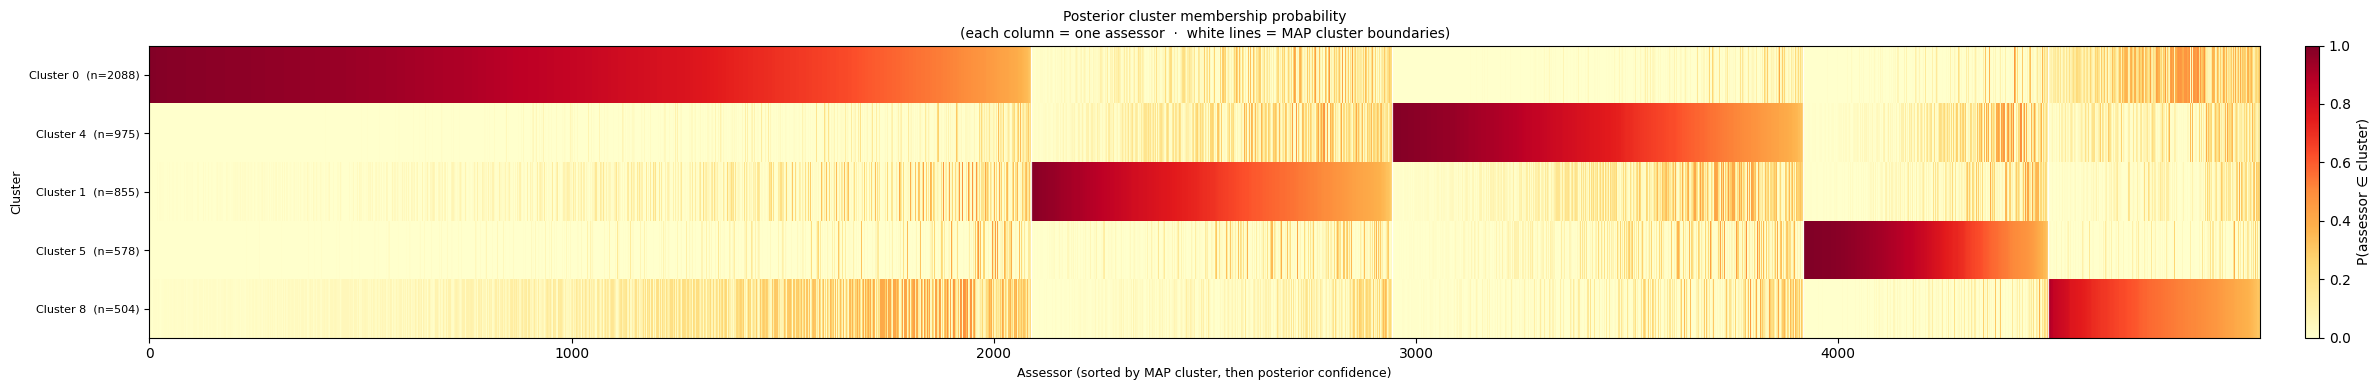


5 active clusters out of 10
Cluster sizes: Cl0=2088, Cl4=975, Cl1=855, Cl5=578, Cl8=504


In [18]:
active_clusters, cluster_sizes = plot_membership_heatmap(
   results_9["z_map"], results_9["membership"], C
)

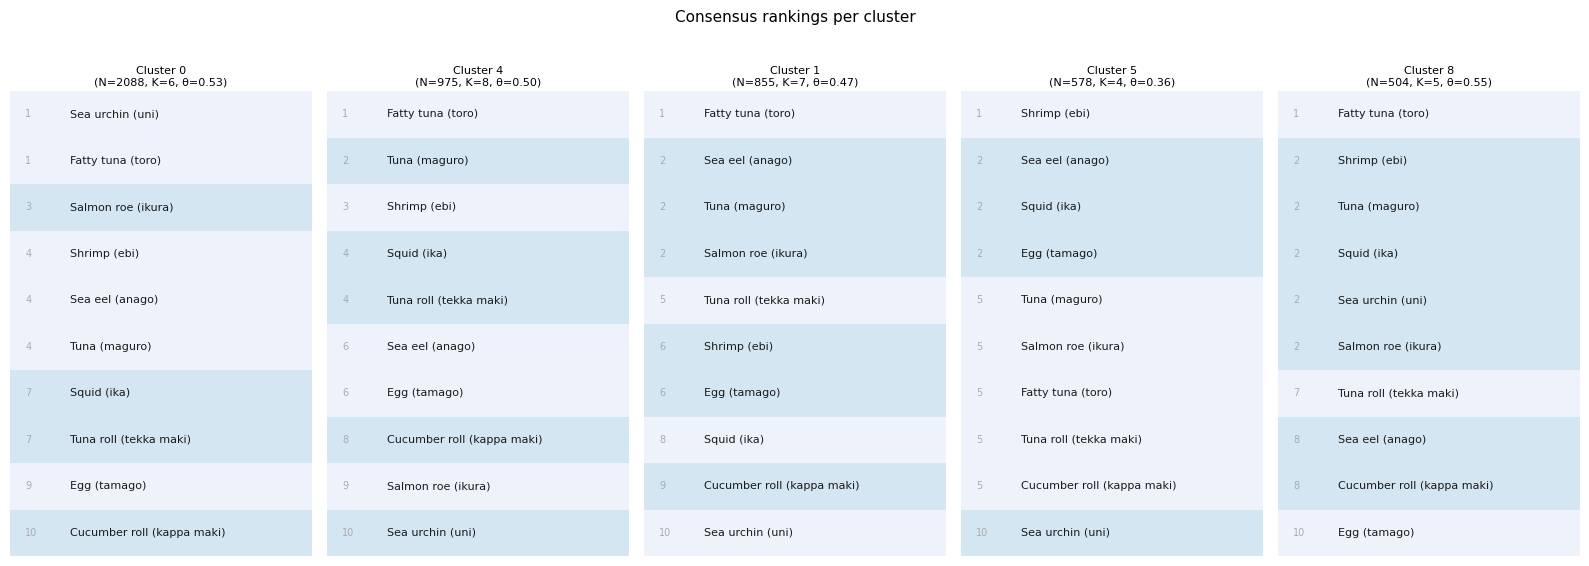

Showing 5/10 clusters (filter: ≥10 assessors)


In [27]:
clusters_info = {c: results_9[c] for c in range(C) if c in results_9}
cluster_order_9 = plot_consensus_rankings(
    clusters_info, results_9["z_map"], sushi_names, rankings, C, min_assessors=10
)

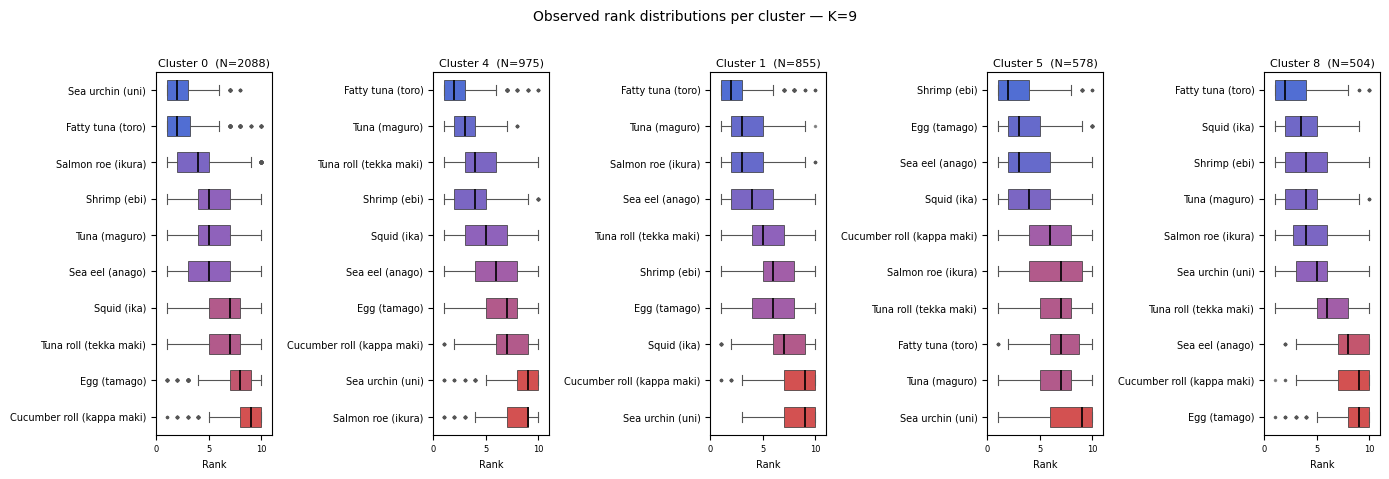

In [29]:
cluster_sizes_9 = np.array([(results_9["z_map"] == c).sum() for c in range(C)])
active_clusters = [c for c in np.argsort(-cluster_sizes_9) if cluster_sizes_9[c] > 0]
plot_rank_distributions(cluster_order_9, cluster_sizes_9, results_9["z_map"], rankings, sushi_names, title="K=9")

 K_init  K_actual_mean  elpd_mean  elpd_std  se_mean  p_loo_mean  n_bad_k_mean  n_very_bad_k_mean  delta_elpd
      2            2.0  -69313.51    421.38   120.75       12.16          46.2               19.0    -1255.55
      3            3.0  -68844.92     50.09   120.37       53.18          40.6               14.2     -786.97
      4            4.0  -68658.01     85.03   121.06       46.60         164.6               92.4     -600.06
      5            5.0  -68442.02     77.10   121.79       80.09          20.0                0.0     -384.07
      6            6.0  -68400.88     72.98   121.54      114.94           3.8                0.2     -342.93
      7            6.6  -68281.28     93.54   122.13      160.18           8.6                1.2     -223.32
      8            8.0  -68180.33     92.19   123.11      227.89           8.2                0.8     -122.37
      9            8.8  -68074.28     32.60   123.61      207.62          38.6                0.8      -16.32
     10   

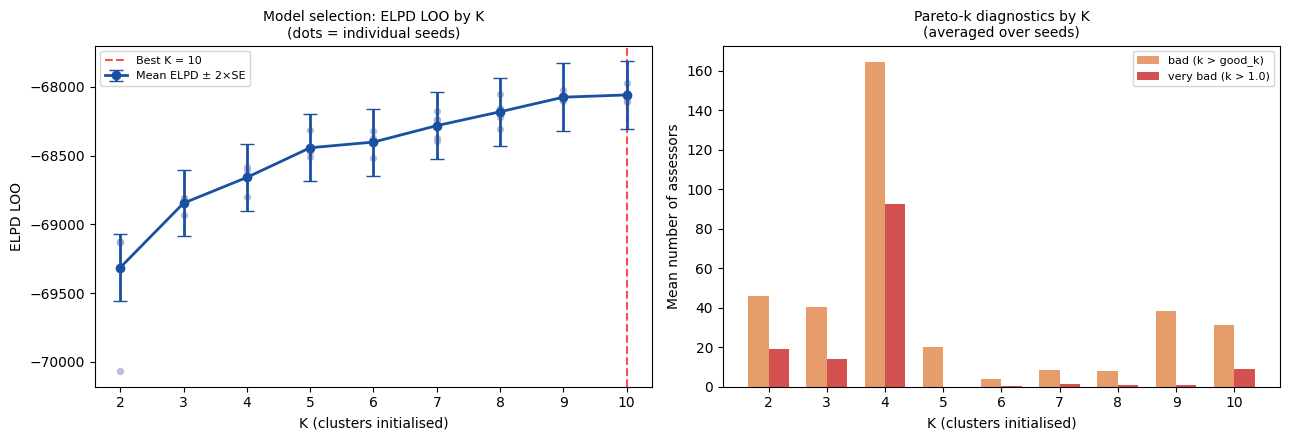


Best K by mean ELPD: 10


In [13]:

# ── Model selection from timm_runs (multi-seed) ───────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUNS_DIR = Path("timm_runs")
K_values = sorted({
    int(p.stem.split("_")[0][1:])
    for p in RUNS_DIR.glob("K*.json")
})

# Load all runs
all_runs = []
for p in sorted(RUNS_DIR.glob("K*.json")):
    with open(p) as f:
        all_runs.append(json.load(f))

df_runs = pd.DataFrame(all_runs)[["K_init", "K_actual", "seed", "elpd", "se", "p_loo",
                                   "n_bad_k", "n_very_bad_k"]]

# Aggregate per K_init: mean ELPD, pooled SE, mean diagnostics
agg = (
    df_runs.groupby("K_init")
    .agg(
        K_actual_mean=("K_actual", "mean"),
        elpd_mean=("elpd", "mean"),
        elpd_std=("elpd", "std"),
        se_mean=("se", "mean"),
        p_loo_mean=("p_loo", "mean"),
        n_bad_k_mean=("n_bad_k", "mean"),
        n_very_bad_k_mean=("n_very_bad_k", "mean"),
        n_seeds=("seed", "count"),
    )
    .reset_index()
)

# ΔELPD vs best model
best_elpd = agg["elpd_mean"].max()
agg["delta_elpd"] = agg["elpd_mean"] - best_elpd

print(agg[["K_init", "K_actual_mean", "elpd_mean", "elpd_std", "se_mean",
           "p_loo_mean", "n_bad_k_mean", "n_very_bad_k_mean", "delta_elpd"]].round(2).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ELPD curve — mean ± 2×SE across seeds, with individual seed dots
ax = axes[0]
for run in all_runs:
    ax.scatter(run["K_init"], run["elpd"], color="#aaaacc", s=18, zorder=3, alpha=0.7)

ax.errorbar(
    agg["K_init"], agg["elpd_mean"],
    yerr=2 * agg["se_mean"],
    marker="o", markersize=6, linewidth=2,
    capsize=5, color="#1a50a0", label="Mean ELPD ± 2×SE",
    zorder=4,
)

best_K = int(agg.loc[agg["elpd_mean"].idxmax(), "K_init"])
ax.axvline(best_K, linestyle="--", color="red", alpha=0.7, label=f"Best K = {best_K}")
ax.set_xlabel("K (clusters initialised)", fontsize=10)
ax.set_ylabel("ELPD LOO", fontsize=10)
ax.set_title("Model selection: ELPD LOO by K\n(dots = individual seeds)", fontsize=10)
ax.set_xticks(K_values)
ax.legend(fontsize=8)

# Right: Pareto-k diagnostics
ax = axes[1]
bar_w = 0.35
x = np.array(K_values)
ax.bar(x - bar_w/2, agg["n_bad_k_mean"],      width=bar_w, label="bad (k > good_k)",  alpha=0.75, color="#e07b39")
ax.bar(x + bar_w/2, agg["n_very_bad_k_mean"], width=bar_w, label="very bad (k > 1.0)", alpha=0.85, color="#cc3333")
ax.set_xlabel("K (clusters initialised)", fontsize=10)
ax.set_ylabel("Mean number of assessors", fontsize=10)
ax.set_title("Pareto-k diagnostics by K\n(averaged over seeds)", fontsize=10)
ax.set_xticks(K_values)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("timm_model_selection_multi_seed.png", dpi=150)
plt.show()

print(f"\nBest K by mean ELPD: {best_K}")


In [41]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# ── Choose a run directory ────────────────────────────────────────────────────
SUSHI_RUNS_DIR = Path("sushi3/runs")
run_name = f"sushi_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir  = SUSHI_RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# ── 1. MCMC parameters — human-readable JSON ─────────────────────────────────
mcmc_params = dict(
    # Data
    n_assessors   = len(rankings),
    n_items       = rankings.shape[1],
    # Cluster init
    C             = C,
    # run_mcmc call
    n_iter        = n_iter,
    burn_in       = burn_in,
    thin          = thin,
    n_item_moves_per_cluster = 1,
    a_theta       = 2,
    b_theta       = 1,
    theta_jump    = 10,
    ranking_jump  = 5,
    use_annealing = True,
    temp_min      = 0.1,
    temp_max      = 1.0,
    # Provenance
    run_name      = run_name,
    saved_at      = datetime.now().isoformat(),
)
with open(run_dir / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params, f, indent=2)

# ── 2. MAP result — JSON ─────────────────────────────────────────────────────
if samples_partial is not None:
    map_serialisable = {}
    for key, val in summaries_partial.items():
        if isinstance(val, (int, float, str, bool)):
            map_serialisable[key] = val
        elif isinstance(val, np.integer):
            map_serialisable[key] = int(val)
        elif isinstance(val, np.floating):
            map_serialisable[key] = float(val)
        elif isinstance(val, (list, dict)):
            map_serialisable[key] = val
    with open(run_dir / "map_result.json", "w") as f:
        json.dump(map_serialisable, f, indent=2, default=str)

# ── 3. Full MCMC samples — pickle ────────────────────────────────────────────
with open(run_dir / "samples.pkl", "wb") as f:
    pickle.dump(samples_partial, f)

# ── 4. Final model state — pickle ────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_partial, f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Run saved to: {run_dir}")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run saved to: sushi3\runs\sushi_20260511_142852
  final_state.pkl                39.8 KB
  map_result.json               508.5 KB
  mcmc_params.json                0.4 KB
  samples.pkl                417143.1 KB


In [13]:
import json
import pickle
from pathlib import Path

# ── Select run to load ────────────────────────────────────────────────────────
RUN_NAME = "sushi_20260413_155012"  # or paste a specific name, e.g. "sushi_20260410_153000"
run_dir  = Path("sushi3/runs") / RUN_NAME

# ── 1. MCMC parameters ────────────────────────────────────────────────────────
with open(run_dir / "mcmc_params.json") as f:
    mcmc_params = json.load(f)

C             = mcmc_params["C"]
gamma         = mcmc_params["gamma"]
delta         = mcmc_params["delta"]

print(f"Run: {RUN_NAME}")
print(f"  C={C}, n_assessors={mcmc_params['n_assessors']}, n_items={mcmc_params['n_items']}")

# ── 2. MCMC samples ──────────────────────────────────────────────────────────
with open(run_dir / "samples.pkl", "rb") as f:
    samples_partial = pickle.load(f)

# ── 3. Final model state ─────────────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "rb") as f:
    final_state_partial = pickle.load(f)

# ── 4. MAP result (if saved) ─────────────────────────────────────────────────
map_path = run_dir / "map_result.json"
if map_path.exists():
    with open(map_path) as f:
        summaries_partial = json.load(f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nLoaded successfully:")
print(f"  {len(samples_partial.z_samples)} posterior samples")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run: sushi_20260413_155012
  C=20, n_assessors=5000, n_items=10

Loaded successfully:
  20000 posterior samples
  final_state.pkl                41.2 KB
  map_result.json              1548.4 KB
  mcmc_params.json                0.4 KB
  samples.pkl                808666.4 KB


In [35]:
# ── Sushi item names for ITEM SET A (sushi3a) ─────────────────────────────────
# NB: Item set A has DIFFERENT items 5-9 than item set B!
#   A: 5=ikura, 6=tamago, 7=toro, 8=tekka_maki, 9=kappa_maki
#   B: 5=tako,  6=ikura,  7=tamago, 8=toro,      9=amaebi
sushi_names = {
    0: "Shrimp (ebi)",
    1: "Sea eel (anago)",
    2: "Tuna (maguro)",
    3: "Squid (ika)",
    4: "Sea urchin (uni)",
    5: "Salmon roe (ikura)",
    6: "Egg (tamago)",
    7: "Fatty tuna (toro)",
    8: "Tuna roll (tekka maki)",
    9: "Cucumber roll (kappa maki)",
}

n_ranked = rankings.shape[1]
print(f"Sushi items in rankings (item set A): {n_ranked}")
for i in range(n_ranked):
    print(f"  {i}: {sushi_names[i]}")

Sushi items in rankings (item set A): 10
  0: Shrimp (ebi)
  1: Sea eel (anago)
  2: Tuna (maguro)
  3: Squid (ika)
  4: Sea urchin (uni)
  5: Salmon roe (ikura)
  6: Egg (tamago)
  7: Fatty tuna (toro)
  8: Tuna roll (tekka maki)
  9: Cucumber roll (kappa maki)


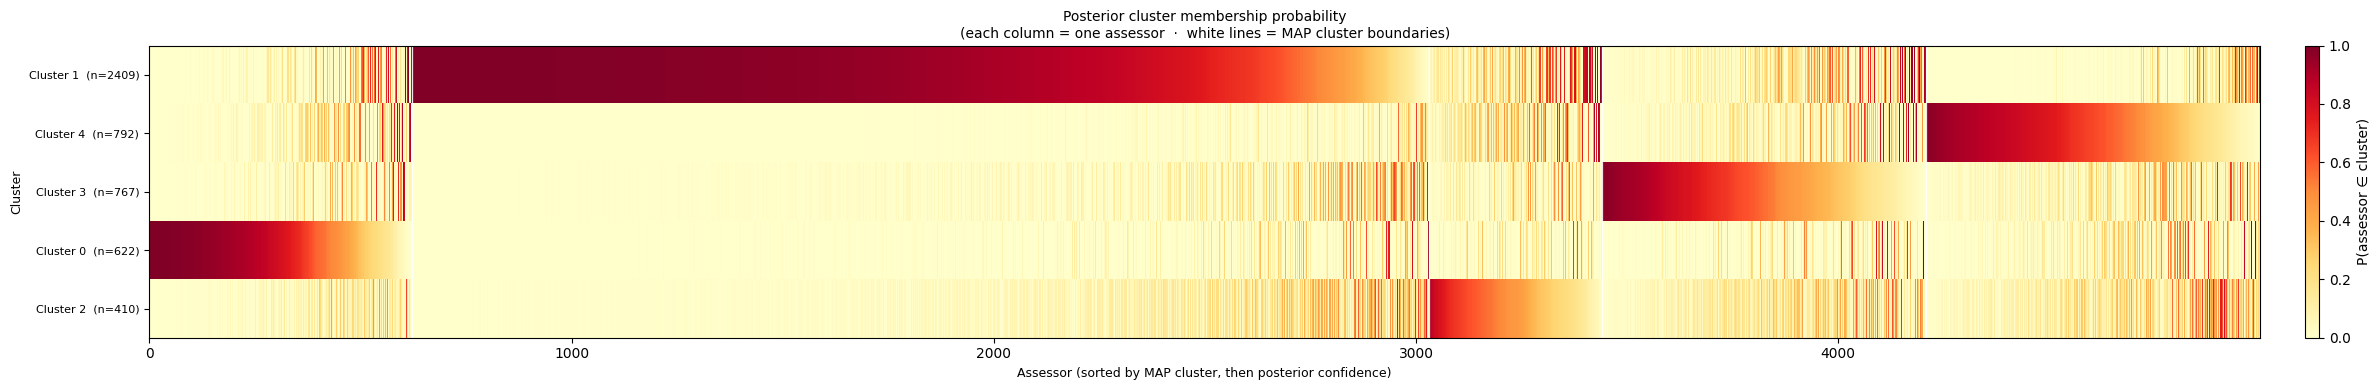


5 active clusters out of 5
Cluster sizes: Cl1=2409, Cl4=792, Cl3=767, Cl0=622, Cl2=410


In [ ]:
# ── Posterior cluster membership heatmap ──────────────────────────────────────

z_arr    = np.array(samples_partial.z_samples, dtype=np.intp)  # (T, N)
T_samp   = z_arr.shape[0]
N_assess = z_arr.shape[1]

# Use MAP z from find_map (or estimate_map labels as fallback)
if "map_result" in dir() and map_result is not None:
    z_map = map_result["z"]
elif "summaries_partial" in dir() and "labels" in summaries_partial:
    z_map = summaries_partial["labels"]
else:
    raise RuntimeError("Run find_map() or estimate_map() first")

# Build membership matrix from posterior samples
membership = np.zeros((N_assess, C), dtype=np.float32)
for t in range(T_samp):
    membership[np.arange(N_assess), z_arr[t]] += 1
membership /= T_samp

z_map_arr = np.array(z_map)
active_clusters, cluster_sizes = plot_membership_heatmap(z_map_arr, membership, C)


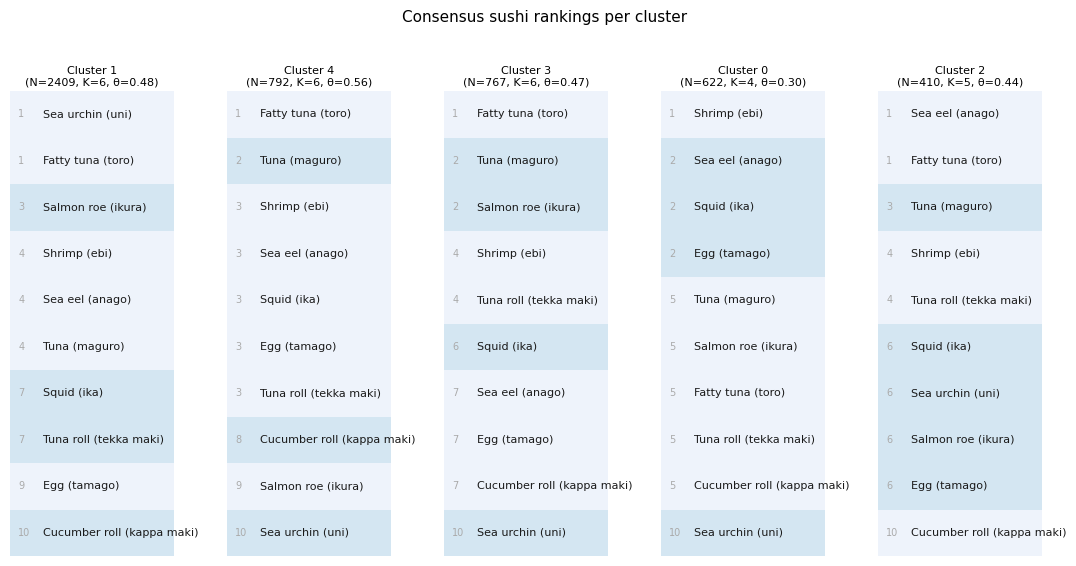

Showing 5/5 clusters (filter: ≥10 assessors)


In [ ]:
# ── Consensus rankings per cluster ────────────────────────────────────────────
MIN_ASSESSORS = 10

_theta_samples = (
    np.array(samples_partial.theta_samples)
    if hasattr(samples_partial, "theta_samples") and samples_partial.theta_samples is not None
    else None
)

# Build clusters_info from whichever MAP result is available
clusters_info = {}
for c in active_clusters:
    if "map_result" in dir() and map_result is not None:
        bl    = map_result["clusters"][c]["blocks"]
        theta = map_result["clusters"][c].get("theta", 0.0)
    else:
        info  = summaries_partial["consensus_blocks"][c]
        bl    = info["blocks_hat"]
        theta = float(_theta_samples[:, c].mean()) if _theta_samples is not None else 0.0
    clusters_info[c] = {"blocks": bl, "theta": theta, "cluster_size": int(cluster_sizes[c])}

cluster_order = plot_consensus_rankings(
    clusters_info, z_map_arr, sushi_names, rankings, C, min_assessors=MIN_ASSESSORS
)


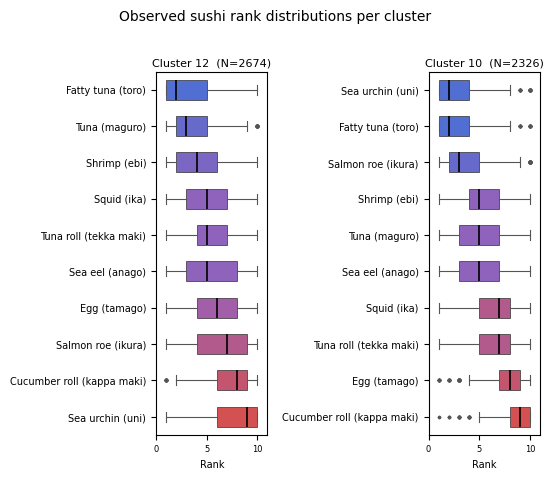

In [ ]:
# ── Observed rank distributions per cluster (box plots) ───────────────────────
plot_rank_distributions(
    cluster_order, cluster_sizes, z_map_arr, rankings, sushi_names
)


In [14]:
pip install arviz 

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------- ----------------- 0.8/1.4 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------- ----------------- 0.8/1.4 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.6 MB/s  0:00:00

   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   ---------- ----------------------------- 2/8 [arviz_stats]
   --------------- ------------------------ 3/8 [xarray]
   -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


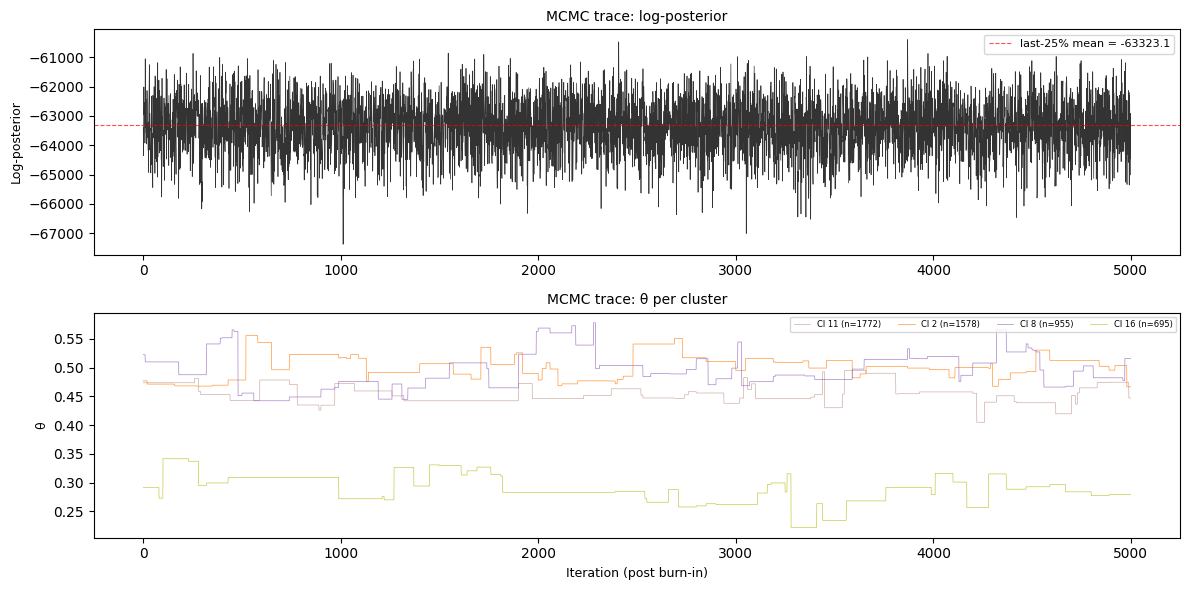

In [65]:
# ── MCMC diagnostics: log-posterior trace + theta traces ──────────────────────
import matplotlib.pyplot as plt

has_logp  = hasattr(samples_partial, "logp") and samples_partial.logp is not None
has_theta = hasattr(samples_partial, "theta_samples") and samples_partial.theta_samples is not None
n_panels  = int(has_logp) + int(has_theta)

if n_panels == 0:
    print("No logp or theta samples saved — run MCMC with save_logp=True, save_theta=True")
else:
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels), squeeze=False)
    ax_idx = 0

    # 1. Log-posterior trace
    if has_logp:
        logp = np.array(samples_partial.logp)
        ax = axes[ax_idx, 0]
        ax.plot(logp, lw=0.5, color="#333333")
        ax.set_ylabel("Log-posterior", fontsize=9)
        ax.set_title("MCMC trace: log-posterior", fontsize=10)
        tail = logp[-len(logp)//4:]
        ax.axhline(tail.mean(), color="red", ls="--", lw=0.8, alpha=0.7,
                   label=f"last-25% mean = {tail.mean():.1f}")
        ax.legend(fontsize=8)
        ax_idx += 1

    # 2. Theta traces (one line per active cluster)
    if has_theta:
        theta_arr = np.array(samples_partial.theta_samples)  # (T, C)
        ax = axes[ax_idx, 0]
        cmap_theta = plt.get_cmap("tab20", C)
        for c in active_clusters:
            ax.plot(theta_arr[:, c], lw=0.5, color=cmap_theta(c), alpha=0.8,
                    label=f"Cl {c} (n={cluster_sizes[c]})")
        ax.set_ylabel("θ", fontsize=9)
        ax.set_xlabel("Iteration (post burn-in)", fontsize=9)
        ax.set_title("MCMC trace: θ per cluster", fontsize=10)
        ax.legend(fontsize=6, ncol=4, loc="upper right")

    plt.tight_layout()
    plt.show()

# Bayesian rank clustering data

In [34]:
"""
Extract the Tohoku sushi ranking subset used in:

  Pearce & Johnson (2024). "Bayesian Rank-Clustering." Psychometrika.

The paper uses complete rankings of 10 sushi types from respondents who
lived in Japan's Tohoku region until at least 15 years of age (n=280),
following Piancastelli & Friel (2025).

Data source:
  Kamishima, T. (2003). "Nantonac Collaborative Filtering."
  SUSHI Preference Data Set: https://www.kamishima.net/sushi/
  Download "All Data Set": sushi3-2016.zip
"""

import csv
import os
import sys
import numpy as np
from pathlib import Path

# ──────────────────────────────────────────────────────────────────────
# Configuration — point to the extracted sushi3-2016 folder
# ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("sushi3/sushi3-2016")

# File paths within the extracted archive
UDATA_FILE = DATA_DIR / "sushi3.udata"        # user demographics
ORDER_FILE = DATA_DIR / "sushi3a.5000.10.order"  # complete rankings of 10 sushi types

# ──────────────────────────────────────────────────────────────────────
# sushi3.udata column layout (tab-separated, from README-en.txt):
#
#   Col 0: user_id
#   Col 1: gender           — 0 = male, 1 = female
#   Col 2: age_group        — 0 = 15–19, 1 = 20–29, …, 5 = 60+
#   Col 3: total_time       — total survey time in seconds
#   Col 4: prefecture_15    — prefecture ID where respondent lived most until age 15
#   Col 5: region_15        — region ID where respondent lived most until age 15
#   Col 6: prefecture_now   — current prefecture ID
#   Col 7: region_now       — current region ID
#   Col 8: same_pref_flag   — 1 if prefecture_15 == prefecture_now, else 0
#   Col 9+: additional fields
#
# Region codes:
#   0 = Hokkaido, 1 = Tohoku, 2 = Kanto, 3 = Chubu, 4 = Kinki,
#   5 = Chugoku, 6 = Shikoku, 7 = Kyushu
# ──────────────────────────────────────────────────────────────────────

REGION_15_COL = 5   # column index for "region lived in until age 15"
TOHOKU_CODE = 1     # region code for Tohoku

# Sushi item IDs (set A, 0-indexed)
SUSHI_NAMES = {
    0: "ebi (shrimp)",
    1: "anago (sea eel)",
    2: "maguro (tuna)",
    3: "ika (squid)",
    4: "uni (sea urchin)",
    5: "ikura (salmon roe)",
    6: "tamago (egg)",
    7: "toro (fatty tuna)",
    8: "tekka-maki (tuna roll)",
    9: "kappa-maki (cucumber roll)",
}


def load_user_demographics(filepath: Path) -> list[list[str]]:
    """Load sushi3.udata (tab-separated) and return list of row-lists."""
    rows = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(line.split("\t"))
    print(f"Loaded {len(rows)} user records from {filepath}")
    return rows


def load_rankings(filepath: Path) -> list[list[int]]:
    """
    Load sushi3a.5000.10.order and return list of ranking vectors.

    Each ranking vector is a list of 10 sushi IDs ordered from most
    preferred (position 0) to least preferred (position 9).
    """
    rankings = []
    with open(filepath, "r") as f:
        for i, line in enumerate(f):
            if i == 0:
                continue  # skip header line
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # Format: 0 <num_items> <item_1> ... <item_num_items>
            num_items = int(parts[1])
            items = [int(x) for x in parts[2 : 2 + num_items]]
            rankings.append(items)
    print(f"Loaded {len(rankings)} rankings from {filepath}")
    return rankings


def filter_tohoku(
    users: list[list[str]], rankings: list[list[int]]
) -> tuple[list[int], list[list[int]]]:
    """
    Filter to respondents whose region_15 == Tohoku (code 1).

    Returns (indices, filtered_rankings).
    """
    assert len(users) == len(rankings), (
        f"Mismatch: {len(users)} users vs {len(rankings)} rankings"
    )

    indices = []
    filtered = []
    for i, row in enumerate(users):
        region_15 = int(row[REGION_15_COL])
        if region_15 == TOHOKU_CODE:
            indices.append(i)
            filtered.append(rankings[i])

    print(f"Tohoku subset: {len(filtered)} respondents (expected: 280)")
    return indices, filtered


def ranking_to_rank_vector(ranking: list[int], n_items: int = 10) -> list[int]:
    """
    Convert a preference ordering to a rank vector.

    Input:  ranking[k] = sushi ID at position k (0 = most preferred)
    Output: ranks[j]   = rank of sushi j (1 = most preferred)
    """
    ranks = [0] * n_items
    for position, item_id in enumerate(ranking):
        ranks[item_id] = position + 1  # 1-indexed rank
    return ranks


def save_tohoku_data(
    indices: list[int],
    rankings: list[list[int]],
    out_dir: Path = Path("."),
):
    """Save the Tohoku subset in several convenient formats."""
    os.makedirs(out_dir, exist_ok=True)
    n = len(rankings)
    n_items = 10

    # 1. Rankings as preference orderings
    orderings_file = out_dir / "tohoku_sushi_orderings.csv"
    with open(orderings_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([f"choice_{k+1}" for k in range(n_items)])
        for ranking in rankings:
            writer.writerow(ranking)
    print(f"Saved preference orderings to {orderings_file}")

    # 2. Rank matrix
    rank_matrix_file = out_dir / "tohoku_sushi_ranks.csv"
    with open(rank_matrix_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([SUSHI_NAMES[j] for j in range(n_items)])
        for ranking in rankings:
            writer.writerow(ranking_to_rank_vector(ranking, n_items))
    print(f"Saved rank matrix to {rank_matrix_file}")

    # 3. NumPy array
    rank_matrix = np.array(
        [ranking_to_rank_vector(r, n_items) for r in rankings], dtype=int
    )
    npy_file = out_dir / "tohoku_sushi_ranks.npy"
    np.save(npy_file, rank_matrix)
    print(f"Saved numpy rank matrix ({rank_matrix.shape}) to {npy_file}")

    # 4. Summary statistics
    print(f"\n{'='*60}")
    print(f"TOHOKU SUSHI DATA SUMMARY")
    print(f"{'='*60}")
    print(f"Number of respondents:  {n}")
    print(f"Number of sushi types:  {n_items}")
    print(f"\nMean rank per sushi type (1 = most preferred):")
    mean_ranks = rank_matrix.mean(axis=0)
    sorted_idx = np.argsort(mean_ranks)
    for j in sorted_idx:
        print(f"  {mean_ranks[j]:5.2f}  {SUSHI_NAMES[j]}")


# ── Run ───────────────────────────────────────────────────────────────
if not UDATA_FILE.exists():
    raise FileNotFoundError(
        f"{UDATA_FILE} not found. Download sushi3-2016.zip from "
        "https://www.kamishima.net/sushi/ and extract to sushi3/"
    )
if not ORDER_FILE.exists():
    raise FileNotFoundError(f"{ORDER_FILE} not found.")

users = load_user_demographics(UDATA_FILE)
all_rankings = load_rankings(ORDER_FILE)

indices, tohoku_rankings = filter_tohoku(users, all_rankings)

# If we don't get exactly 280, try other column indices
if len(tohoku_rankings) != 280:
    print(f"\nNote: got {len(tohoku_rankings)} instead of expected 280.")
    print("Trying alternative column indices for region_15...")
    for alt_col in range(len(users[0])):
        if alt_col == REGION_15_COL:
            continue
        try:
            count = sum(1 for row in users if int(row[alt_col]) == TOHOKU_CODE)
            if count == 280:
                print(f"  → Column {alt_col} yields 280 Tohoku respondents!")
                indices = []
                tohoku_rankings = []
                for i, row in enumerate(users):
                    if int(row[alt_col]) == TOHOKU_CODE:
                        indices.append(i)
                        tohoku_rankings.append(all_rankings[i])
                break
        except (ValueError, IndexError):
            continue

save_tohoku_data(indices, tohoku_rankings, out_dir=Path("tohoku_output"))

Loaded 5000 user records from sushi3\sushi3-2016\sushi3.udata
Loaded 5000 rankings from sushi3\sushi3-2016\sushi3a.5000.10.order
Tohoku subset: 280 respondents (expected: 280)
Saved preference orderings to tohoku_output\tohoku_sushi_orderings.csv
Saved rank matrix to tohoku_output\tohoku_sushi_ranks.csv
Saved numpy rank matrix ((280, 10)) to tohoku_output\tohoku_sushi_ranks.npy

TOHOKU SUSHI DATA SUMMARY
Number of respondents:  280
Number of sushi types:  10

Mean rank per sushi type (1 = most preferred):
   3.34  toro (fatty tuna)
   4.37  maguro (tuna)
   4.41  ebi (shrimp)
   5.08  uni (sea urchin)
   5.09  ikura (salmon roe)
   5.33  anago (sea eel)
   6.00  tekka-maki (tuna roll)
   6.17  ika (squid)
   7.16  tamago (egg)
   8.05  kappa-maki (cucumber roll)


In [35]:
# Convert Tohoku rankings to numpy array for the model
rankings_tohoku = np.array(tohoku_rankings)  # shape (280, 10)
print(f"Tohoku rankings: {rankings_tohoku.shape[0]} assessors, {rankings_tohoku.shape[1]} sushi types")
print(f"Items: {sorted(np.unique(rankings_tohoku))}")

Tohoku rankings: 280 assessors, 10 sushi types
Items: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [36]:
C_tohoku = 20
gamma_tohoku = 1
delta_tohoku = 0.5

clusters_tohoku, z_init_tohoku = init_spectral_with_z(
    rankings=rankings_tohoku,
    n_clusters=C_tohoku,
    py_sampling=False,
    gamma=gamma_tohoku,
    delta=delta_tohoku,
    seed=123
)

In [37]:
n_iter_tohoku = 50000
burn_in_tohoku = 30000
thin_tohoku = 1
init_mu_tohoku = [0.001 for _ in range(C_tohoku)]

model_tohoku = MixtureRankingModel(
    rankings=rankings_tohoku,
    init_clusters=clusters_tohoku,
    init_z=z_init_tohoku,
    init_mu=init_mu_tohoku,
    seed=123,
    verbose=True,
    init_theta=1.0,
)

final_state_tohoku, samples_tohoku = model_tohoku.run_mcmc(
    n_iter=n_iter_tohoku,
    burn_in=burn_in_tohoku,
    thin=thin_tohoku,
    use_py_prior=False,
    include_order_prior=False,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    ranking_jump=5,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

model_tohoku.print_acceptance_summary()

if samples_tohoku is not None:
    summaries_tohoku = model_tohoku.estimate_map(samples_tohoku, ci=0.95)
    print("MAP summaries:", summaries_tohoku)

[Model] Initialized: N=280 assessors, n=10 items, C=20 clusters, n_pairs=45
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    280×45  (0.0 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 5 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 12: 5 blocks, theta=1.000

C:\Users\jonanord\AppData\Local\Temp\ipykernel_30668\3039478152.py:40: DeprecationWarning: estimate_map() is deprecated and will be removed in a future version. Use find_map(method='frequency', ci=...) instead.
  summaries_tohoku = model_tohoku.estimate_map(samples_tohoku, ci=0.95)


MAP summaries: {'N': 280, 'C': 20, 'T': 20000, 'labels': {'p_ic': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0,

In [38]:
map_result_tohoku = model_tohoku.find_map(samples_tohoku, refine=True, verbose=True)

z_map_tohoku = map_result_tohoku["z"]
for c, cl in enumerate(map_result_tohoku["clusters"]):
    if c in z_map_tohoku:
        print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=4366 with logp=-2256.2287
  Cluster 11: 0 moves in 1 sweeps, K=5 blocks
[MAP] logp: -2256.2287 → -2256.2287 (Δ=+0.0000)
Cluster 11: [[7], [0, 1, 2, 4, 5], [3, 8], [6], [9]]


In [39]:
import json
import pickle
from pathlib import Path
from datetime import datetime

SUSHI_RUNS_DIR_TOHOKU = Path("sushi3/runs")
run_name_tohoku = f"sushi_tohoku_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir_tohoku  = SUSHI_RUNS_DIR_TOHOKU / run_name_tohoku
run_dir_tohoku.mkdir(parents=True, exist_ok=True)

mcmc_params_tohoku = dict(
    n_assessors   = len(rankings_tohoku),
    n_items       = rankings_tohoku.shape[1],
    subset        = "Tohoku (region_15 == 1)",
    C             = C_tohoku,
    gamma         = gamma_tohoku,
    delta         = delta_tohoku,
    n_iter        = n_iter_tohoku,
    burn_in       = burn_in_tohoku,
    thin          = thin_tohoku,
    n_item_moves_per_cluster = 1,
    a_theta       = 4,
    b_theta       = 1,
    theta_jump    = 10,
    ranking_jump  = 5,
    use_annealing = True,
    temp_min      = 0.1,
    temp_max      = 1.0,
    run_name      = run_name_tohoku,
    saved_at      = datetime.now().isoformat(),
)
with open(run_dir_tohoku / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params_tohoku, f, indent=2)

if samples_tohoku is not None:
    map_ser = {}
    for key, val in summaries_tohoku.items():
        if isinstance(val, (int, float, str, bool)):
            map_ser[key] = val
        elif isinstance(val, np.integer):
            map_ser[key] = int(val)
        elif isinstance(val, np.floating):
            map_ser[key] = float(val)
        elif isinstance(val, (list, dict)):
            map_ser[key] = val
    with open(run_dir_tohoku / "map_result.json", "w") as f:
        json.dump(map_ser, f, indent=2, default=str)

with open(run_dir_tohoku / "samples.pkl", "wb") as f:
    pickle.dump(samples_tohoku, f)

with open(run_dir_tohoku / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_tohoku, f)

print(f"Run saved to: {run_dir_tohoku}")
for p in sorted(run_dir_tohoku.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run saved to: sushi3\runs\sushi_tohoku_20260508_140539
  final_state.pkl                 4.4 KB
  map_result.json                95.2 KB
  mcmc_params.json                0.4 KB
  samples.pkl                 73919.5 KB


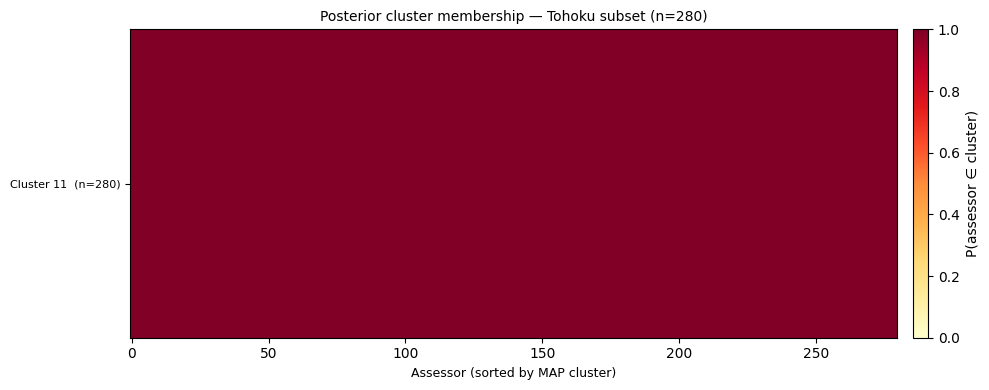


1 active clusters out of 20
Cluster sizes: Cl11=280


In [41]:
# ── Posterior cluster membership heatmap (Tohoku) ─────────────────────────────
import matplotlib.pyplot as plt

z_arr_t   = np.array(samples_tohoku.z_samples, dtype=np.intp)
T_samp_t  = z_arr_t.shape[0]
N_assess_t = z_arr_t.shape[1]

z_map_t = map_result_tohoku["z"]

membership_t = np.zeros((N_assess_t, C_tohoku), dtype=np.float32)
for t in range(T_samp_t):
    membership_t[np.arange(N_assess_t), z_arr_t[t]] += 1
membership_t /= T_samp_t

z_map_arr_t  = np.array(z_map_t, dtype=int)
confidence_t = membership_t[np.arange(N_assess_t), z_map_arr_t]
sort_ord_t   = np.lexsort((-confidence_t, z_map_arr_t))
boundaries_t = np.where(np.diff(z_map_arr_t[sort_ord_t]))[0]

cluster_sizes_t = np.array([(z_map_arr_t == c).sum() for c in range(C_tohoku)])
active_clusters_t = [c for c in np.argsort(-cluster_sizes_t) if cluster_sizes_t[c] > 0]

mem_display_t = membership_t[sort_ord_t][:, active_clusters_t]

fig, ax = plt.subplots(figsize=(max(10, N_assess_t * 0.02 + 4), max(4, len(active_clusters_t) * 0.4 + 2)))
im = ax.imshow(mem_display_t.T, vmin=0, vmax=1, cmap="YlOrRd", aspect="auto", interpolation="nearest")
for b in boundaries_t:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

ax.set_yticks(range(len(active_clusters_t)))
ax.set_yticklabels([f"Cluster {c}  (n={cluster_sizes_t[c]})" for c in active_clusters_t], fontsize=8)
ax.set_xlabel("Assessor (sorted by MAP cluster)", fontsize=9)
ax.set_title("Posterior cluster membership — Tohoku subset (n=280)", fontsize=10)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

print(f"\n{len(active_clusters_t)} active clusters out of {C_tohoku}")
print(f"Cluster sizes: {', '.join(f'Cl{c}={cluster_sizes_t[c]}' for c in active_clusters_t)}")

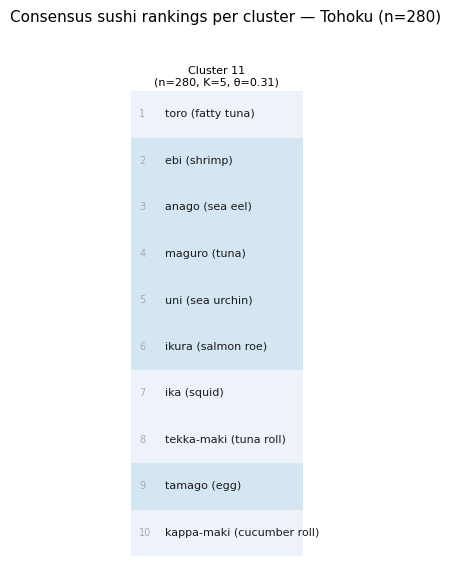

Showing 1/20 clusters (filter: ≥5 assessors)


In [ ]:

# ── Consensus rankings per cluster (Tohoku) ───────────────────────────────────
import matplotlib.pyplot as plt

MIN_ASSESSORS_T = 5
n_ranked_t = rankings_tohoku.shape[1]

cluster_order_t = [c for c in active_clusters_t if cluster_sizes_t[c] >= MIN_ASSESSORS_T]

sushi_names_t = SUSHI_NAMES  # reuse from Tohoku cell

if not cluster_order_t:
    print("No clusters passed the filter — lower MIN_ASSESSORS_T.")
else:
    block_bg = ["#eef3fb", "#d4e6f2"]
    ncols_t = len(cluster_order_t)

    fig, axes = plt.subplots(1, ncols_t, figsize=(ncols_t * 2.2, n_ranked_t * 0.4 + 1.5), squeeze=False)

    for col, c in enumerate(cluster_order_t):
        bl = map_result_tohoku["clusters"][c]["blocks"]
        theta = map_result_tohoku["clusters"][c].get("theta", None)
        lbl = f"θ={theta:.2f}" if theta is not None else ""
        n_c = int(cluster_sizes_t[c])

        total_items = sum(len(b) for b in bl)
        ax = axes[0, col]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, total_items)
        ax.invert_yaxis()
        ax.axis("off")

        rank_pos = 1
        row_i = 0
        for b_idx, block in enumerate(bl):
            toggle = b_idx % 2
            block_rank = rank_pos  # all items in this block share the same rank
            for item_idx in block:
                name = sushi_names_t.get(item_idx, f"item {item_idx}")
                ax.add_patch(plt.Rectangle((0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1))
                ax.text(0.05, row_i + 0.5, str(block_rank), fontsize=7, va="center", ha="left", color="#aaaaaa", zorder=2)
                ax.text(0.20, row_i + 0.5, name, fontsize=8, va="center", ha="left", color="#1a1a1a", zorder=2)
                row_i += 1
            rank_pos += len(block)

        ax.set_title(f"Cluster {c}\n(n={n_c}, K={len(bl)}, {lbl})", fontsize=8, pad=4)

    fig.suptitle("Consensus sushi rankings per cluster — Tohoku (n=280)", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()
    print(f"Showing {ncols_t}/{C_tohoku} clusters (filter: ≥{MIN_ASSESSORS_T} assessors)")


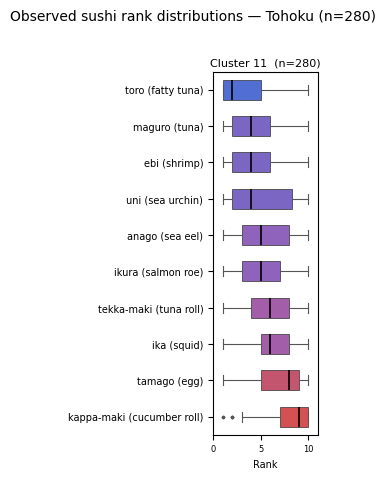

In [43]:
# ── Observed rank distributions per cluster — box plots (Tohoku) ──────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

if not cluster_order_t:
    print("No clusters to plot.")
else:
    ncols_bp_t = len(cluster_order_t)
    rank_cmap_t = mcolors.LinearSegmentedColormap.from_list("bpr", ["#3355cc", "#8844aa", "#cc3333"])

    fig_bp, axes_bp = plt.subplots(1, ncols_bp_t, figsize=(ncols_bp_t * 2.8, n_ranked_t * 0.35 + 1.2), squeeze=False)

    for col, c in enumerate(cluster_order_t):
        cl_assessors = [i for i, z in enumerate(z_map_t) if z == c]
        item_ranks = defaultdict(list)
        for ai in cl_assessors:
            for rank_0, item_idx in enumerate(rankings_tohoku[ai]):
                item_ranks[item_idx].append(rank_0 + 1)

        stats = []
        for item_idx, ranks_list in item_ranks.items():
            arr = np.array(ranks_list)
            stats.append({"item": item_idx, "name": sushi_names_t.get(item_idx, f"item {item_idx}"),
                          "median": np.median(arr), "ranks": ranks_list})
        stats.sort(key=lambda x: x["median"])

        ax = axes_bp[0, col]
        names = [s["name"] for s in stats]
        medians = [s["median"] for s in stats]
        rank_data = [s["ranks"] for s in stats]

        rank_norm = mcolors.Normalize(vmin=min(medians), vmax=max(medians))
        box_colors = [rank_cmap_t(rank_norm(m)) for m in medians]

        bp = ax.boxplot(rank_data, vert=False, patch_artist=True, widths=0.55,
                        flierprops=dict(marker=".", markersize=3, markerfacecolor="#555555",
                                        markeredgecolor="#555555", alpha=0.6),
                        medianprops=dict(color="black", linewidth=1.2),
                        whiskerprops=dict(color="#555555", linewidth=0.8),
                        capprops=dict(color="#555555", linewidth=0.8))
        for patch, fc in zip(bp["boxes"], box_colors):
            patch.set_facecolor(fc)
            patch.set_edgecolor("#333333")
            patch.set_linewidth(0.6)
            patch.set_alpha(0.85)

        ax.set_yticks(range(1, len(stats) + 1))
        ax.set_yticklabels(names, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel("Rank", fontsize=7)
        ax.set_title(f"Cluster {c}  (n={cluster_sizes_t[c]})", fontsize=8, pad=4)
        ax.tick_params(axis="x", labelsize=6)
        ax.set_xlim(0, n_ranked_t + 1)

    fig_bp.suptitle("Observed sushi rank distributions — Tohoku (n=280)", fontsize=10, y=1.01)
    fig_bp.tight_layout()
    plt.show()

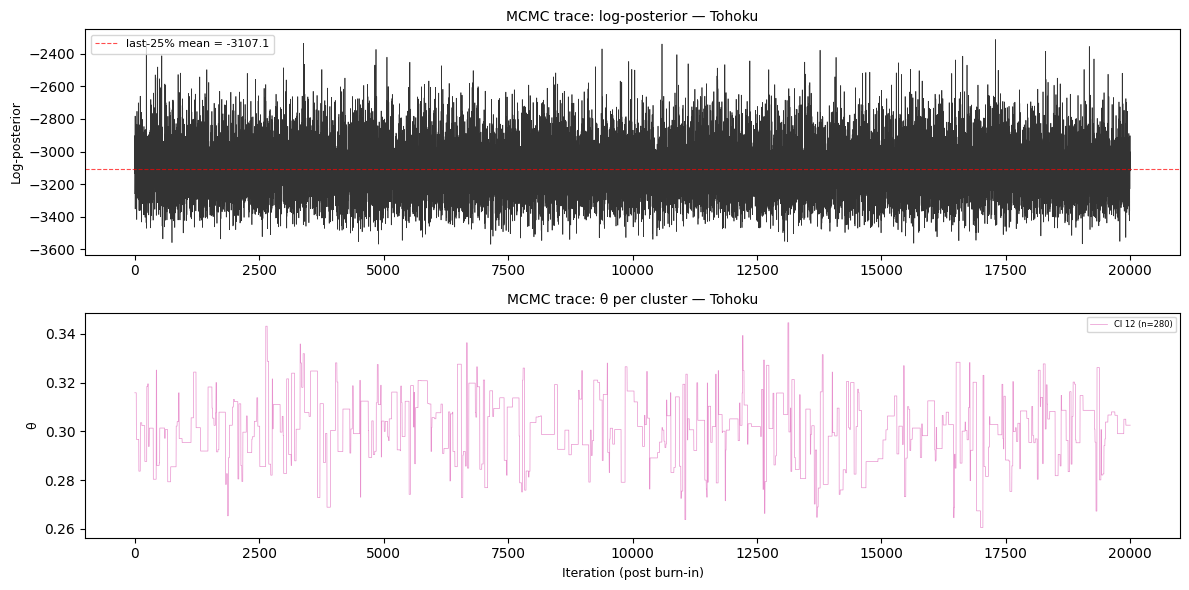

In [76]:
# ── MCMC diagnostics (Tohoku) ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

has_logp_t  = hasattr(samples_tohoku, "logp") and samples_tohoku.logp is not None
has_theta_t = hasattr(samples_tohoku, "theta_samples") and samples_tohoku.theta_samples is not None
n_panels_t  = int(has_logp_t) + int(has_theta_t)

if n_panels_t == 0:
    print("No logp or theta samples saved.")
else:
    fig, axes = plt.subplots(n_panels_t, 1, figsize=(12, 3 * n_panels_t), squeeze=False)
    ax_idx = 0

    if has_logp_t:
        logp_t = np.array(samples_tohoku.logp)
        ax = axes[ax_idx, 0]
        ax.plot(logp_t, lw=0.5, color="#333333")
        ax.set_ylabel("Log-posterior", fontsize=9)
        ax.set_title("MCMC trace: log-posterior — Tohoku", fontsize=10)
        tail = logp_t[-len(logp_t)//4:]
        ax.axhline(tail.mean(), color="red", ls="--", lw=0.8, alpha=0.7,
                   label=f"last-25% mean = {tail.mean():.1f}")
        ax.legend(fontsize=8)
        ax_idx += 1

    if has_theta_t:
        theta_arr_t = np.array(samples_tohoku.theta_samples)
        ax = axes[ax_idx, 0]
        cmap_theta_t = plt.get_cmap("tab20", C_tohoku)
        for c in active_clusters_t:
            ax.plot(theta_arr_t[:, c], lw=0.5, color=cmap_theta_t(c), alpha=0.8,
                    label=f"Cl {c} (n={cluster_sizes_t[c]})")
        ax.set_ylabel("θ", fontsize=9)
        ax.set_xlabel("Iteration (post burn-in)", fontsize=9)
        ax.set_title("MCMC trace: θ per cluster — Tohoku", fontsize=10)
        ax.legend(fontsize=6, ncol=4, loc="upper right")

    plt.tight_layout()
    plt.show()